# Tree-Based Models & Ensembles — Assignment Notebook
### Week 5 | Fill in the blanks, run, reflect

---

**Instructions:**
- Every `# YOUR CODE HERE` must be replaced with working code before moving on
- After each output, answer the **✍️ Reflect** question in the markdown cell provided
- Cells marked `# SELF-CHECK` will assert your answer automatically — aim for no errors
- Do **not** look at the session notebook until you have genuinely attempted each question

> **Mindset:** The blanks are not syntax tests. Each one forces a *decision* — you must choose the right tool, parameter, or formula and justify why.

---


In [ ]:
# Run this cell first — all imports and data loading happen here
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, f1_score,
                             recall_score, precision_score, roc_curve)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.datasets import make_moons
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap, joblib

sns.set_theme(style='whitegrid'); plt.rcParams['figure.figsize'] = [11, 5]

# Load the Telco dataset (used from Section 2 onwards)
url = ("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d"
       "/master/data/Telco-Customer-Churn.csv")
df_raw = pd.read_csv(url)
print(f"Dataset loaded: {df_raw.shape}"); print(df_raw.dtypes.tail(6))


---
## Section 1: Decision Tree Building Blocks

Before using sklearn, prove you understand what a tree *actually does* by implementing the core math yourself.

---

### Q1 — Implement Gini Impurity from Scratch

A Decision Tree evaluates every candidate split by measuring how *impure* the resulting child nodes are. Gini is the most common measure.

$$\text{Gini}(t) = 1 - \sum_{k} p_k^2$$

where $p_k$ is the fraction of samples belonging to class $k$ at node $t$.

**Your task:** Complete the function below. Do not use any sklearn or numpy impurity functions — implement the formula directly.


In [ ]:
def gini_impurity(class_counts):
    """
    Compute Gini impurity for a single node.

    Parameters
    ----------
    class_counts : list or array of ints
        Number of samples per class at this node.
        e.g. [70, 30] means 70 samples of class-0, 30 of class-1

    Returns
    -------
    float : Gini value in [0, 0.5] for binary classification
    """
    total = sum(class_counts)
    if total == 0:
        return 0.0

    # YOUR CODE HERE
    # Hint: compute p_k for each class, then apply the Gini formula
    sum_pk_squared = 0
    for count in class_counts:
        p_k = count / total
        sum_pk_squared += p_k**2
    gini = 1 - sum_pk_squared
    # raise NotImplementedError("Implement gini_impurity()")
    return gini


# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert abs(gini_impurity([100, 0])   - 0.000) < 1e-6, "Pure node should have Gini = 0"
assert abs(gini_impurity([50,  50])  - 0.500) < 1e-6, "Equal split should have Gini = 0.5"
assert abs(gini_impurity([70,  30])  - 0.420) < 1e-6, "70/30 split should have Gini = 0.42"
assert abs(gini_impurity([10,  10, 10]) - round(1 - 3*(1/3)**2, 6)) < 1e-5, "3-class test failed"
print("✅ All gini_impurity checks passed!")

✅ All gini_impurity checks passed!


### Q2 — Implement Shannon Entropy

Entropy is the alternative impurity measure. It measures *information* rather than probability of mislabelling.

$$H(t) = -\sum_{k} p_k \log_2(p_k)$$

**Convention:** $0 \cdot \log_2(0) = 0$ (a class with zero samples contributes nothing).


In [ ]:
import numpy as np # Ensure numpy is imported for np.log2
def entropy(class_counts):
    """
    Compute Shannon entropy for a single node.

    Returns
    -------
    float : entropy in [0, 1] for binary classification
    """
    total = sum(class_counts)
    if total == 0:
        return 0.0

    # YOUR CODE HERE
    # Hint: use math.log2 or np.log2; skip terms where p_k == 0
    h = 0.0
    for count in class_counts:
        if count == 0:
            continue
        p_k = count / total
        h -= p_k * np.log2(p_k)
    # raise NotImplementedError("Implement entropy()")
    return h


# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert abs(entropy([100, 0])  - 0.000) < 1e-6, "Pure node should have H = 0"
assert abs(entropy([50,  50]) - 1.000) < 1e-6, "Equal binary split should have H = 1"
assert abs(entropy([70,  30]) - (-0.7*np.log2(0.7) - 0.3*np.log2(0.3))) < 1e-5
print("✅ All entropy checks passed!")

✅ All entropy checks passed!


### Q3 — Compute Information Gain for a Candidate Split

A tree picks the split that maximises **Information Gain**:

$$\text{IG} = H(\text{parent}) - \sum_{c} \frac{n_c}{n} H(\text{child}_c)$$

**Scenario:** At a node with 1,000 samples (730 non-churners, 270 churners), you are evaluating a split on `Contract_Type`:
- Left child: 600 samples, 510 non-churn / 90 churn
- Right child: 400 samples, 220 non-churn / 180 churn

**Your task:** Use your `entropy()` function to compute the information gain of this split.


In [ ]:
# Use your entropy() function from Q2.
# Fill in the four variables below — do not hard-code the IG formula output.

parent_counts = [730, 270]      # [non-churn, churn] at the parent node
left_counts   = [510,  90]      # counts in the left child
right_counts  = [220, 180]      # counts in the right child

n_total = sum(parent_counts)
n_left  = sum(left_counts)
n_right = sum(right_counts)

# YOUR CODE HERE — compute information gain using your entropy() function
parent_entropy   = entropy(parent_counts)   # H of the parent node
weighted_entropy = (n_left / n_total) * entropy(left_counts) + \
                   (n_right / n_total) * entropy(right_counts)   # weighted average entropy of the two children
information_gain = parent_entropy - weighted_entropy   # IG = parent - weighted children

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert information_gain > 0, "Information gain should be positive for a useful split"
assert information_gain < parent_entropy, "IG cannot exceed parent entropy"
print(f"Parent Entropy:    {parent_entropy:.4f}")
print(f"Weighted Child H:  {weighted_entropy:.4f}")
print(f"Information Gain:  {information_gain:.4f}")
print("✅ Information gain computed correctly!")

Parent Entropy:    0.8415
Weighted Child H:  0.7630
Information Gain:  0.0785
✅ Information gain computed correctly!


✍️ **Reflect 1:** Look at the right child: 220 non-churn vs 180 churn.
Is this child purer or more mixed than the parent? What does a high information gain tell you about the quality of this split? Answer here:

> *Your answer:*
> The right child (220 non-churn vs 180 churn) is more mixed than the parent (730 non-churn vs 270 churn) in terms of class distribution being closer to 50/50. The parent had a 27% churn rate, while the right child has a 45% churn rate. A high information gain (0.0785) indicates that the split was effective in reducing the overall impurity of the system, meaning it successfully separated the classes into more homogeneous groups, even if individual child nodes are not perfectly pure.

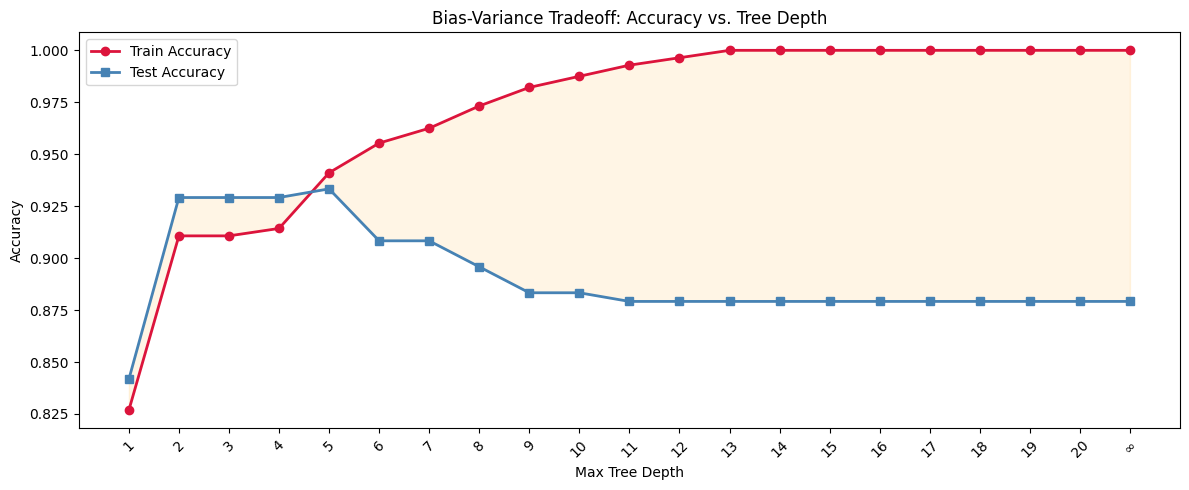

Best test accuracy at depth = 5: 0.9333
Train acc at depth=∞: 1.0000   Test acc at depth=∞: 0.8792
Variance gap at depth=∞: 0.1208


In [ ]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split # Added this import
from sklearn.tree import DecisionTreeClassifier # Ensure DecisionTreeClassifier is imported if not globally available, though it should be from the setup cell
import numpy as np # Ensure numpy is imported for np.argmax
import matplotlib.pyplot as plt # Ensure matplotlib is imported for plotting

X_bv, y_bv = make_moons(n_samples=800, noise=0.30, random_state=42)
X_tr_bv, X_te_bv, y_tr_bv, y_te_bv = train_test_split(
    X_bv, y_bv, test_size=0.30, random_state=42)

depths       = list(range(1, 21)) + [None]
train_scores = []
test_scores  = []

for d in depths:
    # YOUR CODE HERE
    # 1. Instantiate a DecisionTreeClassifier with max_depth=d and random_state=42
    # 2. Fit on (X_tr_bv, y_tr_bv)
    # 3. Append the training accuracy to train_scores
    # 4. Append the test accuracy to test_scores
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_tr_bv, y_tr_bv)
    train_scores.append(dt.score(X_tr_bv, y_tr_bv))
    test_scores.append(dt.score(X_te_bv, y_te_bv))

# Plotting (run as-is after filling the loop)
depth_labels = [str(d) if d else '∞' for d in depths]
plt.figure(figsize=(12, 5))
plt.plot(depth_labels, train_scores, 'o-', color='crimson', lw=2, label='Train Accuracy')
plt.plot(depth_labels, test_scores,  's-', color='steelblue', lw=2, label='Test Accuracy')
plt.fill_between(range(len(depths)), train_scores, test_scores, alpha=0.10, color='orange')
plt.xlabel('Max Tree Depth'); plt.ylabel('Accuracy')
plt.title('Bias-Variance Tradeoff: Accuracy vs. Tree Depth')
plt.legend(); plt.xticks(range(len(depths)), depth_labels, rotation=45)
plt.tight_layout(); plt.show()

best_depth_idx = int(np.argmax(test_scores))
print(f"Best test accuracy at depth = {depth_labels[best_depth_idx]}: {test_scores[best_depth_idx]:.4f}")
print(f"Train acc at depth=∞: {train_scores[-1]:.4f}   Test acc at depth=∞: {test_scores[-1]:.4f}")
print(f"Variance gap at depth=∞: {train_scores[-1] - test_scores[-1]:.4f}")

✍️ **Reflect 2:** The unlimited-depth tree achieves ~100% training accuracy.
- What is the name of this phenomenon?
- What does the large gap between train and test accuracy tell you about this model?
- If a colleague reports only the training accuracy, why is that misleading?

> *Your answer:*
> - The phenomenon where an unlimited-depth tree achieves ~100% training accuracy is called **overfitting**.
> - The large gap between train and test accuracy indicates high **variance**. The model has learned the training data too well, including its noise and specific patterns, and thus struggles to generalize to unseen data.
> - Reporting only training accuracy is misleading because it gives a false sense of the model's performance. A model that overfits will perform poorly on new, real-world data, making the high training accuracy an unreliable indicator of its actual utility or generalizability.

---
## Section 3: Data Prep & The Accuracy Trap

---

### Q5 — Fix the Telco Dataset

The raw Telco CSV has a well-known data quality issue: `TotalCharges` contains whitespace strings where the value is missing, which forces pandas to read the entire column as `object` (string) instead of `float`.

**Your task:** Fix this in three steps — detect, coerce, and impute.


In [ ]:
import pandas as pd
import numpy as np # np is used in the self-check, so ensure it's imported
url = ("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d"
       "/master/data/Telco-Customer-Churn.csv")
df_raw = pd.read_csv(url)

df = df_raw.copy()

# Step 1 — How many rows have a blank/whitespace TotalCharges?
# YOUR CODE HERE: print the count of rows where TotalCharges.str.strip() == ''
n_whitespace = df[df['TotalCharges'].str.strip() == ''].shape[0]
# raise NotImplementedError("Count whitespace rows")
print(f"Rows with whitespace TotalCharges: {n_whitespace}")

# Step 2 — Fix: coerce to numeric (errors → NaN), then impute with the median
# YOUR CODE HERE: convert df['TotalCharges'] to numeric, fill NaN with median
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median()) # Updated this line
# raise NotImplementedError("Fix TotalCharges dtype")

# Step 3 — Encode the target and drop the ID column
df = df.drop(columns=['customerID'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert df['TotalCharges'].dtype in [np.float64, np.float32, float],     f"TotalCharges should be float, got {df['TotalCharges'].dtype}"
assert df['TotalCharges'].isnull().sum() == 0, "No NaN should remain after imputation"
assert set(df['Churn'].unique()) == {0, 1}, "Churn should be binary int"
print(f"✅ Dataset clean. Shape: {df.shape}")
print(f"   Churn rate: {df['Churn'].mean()*100:.1f}%")

Rows with whitespace TotalCharges: 11
✅ Dataset clean. Shape: (7043, 20)
   Churn rate: 26.5%


### Q6 — The Naive Tree and The Trap

Train an **unconstrained** DecisionTreeClassifier on the Telco data (use simple label-encoding for speed — proper pipelines come later).

Then deliberately evaluate it using **only accuracy** first. Then expose the trap by looking at the full report.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report # Added these imports
import numpy as np # Already present, but good to ensure

# Quick label encoding for the naive baseline
df_enc = df.copy()
for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col] = df_enc[col].astype('category').cat.codes

X_naive = df_enc.drop('Churn', axis=1)
y_naive = df_enc['Churn']

X_tr_n, X_te_n, y_tr_n, y_te_n = train_test_split(
    X_naive, y_naive, test_size=0.2, random_state=42, stratify=y_naive)

# YOUR CODE HERE
# 1. Train a DecisionTreeClassifier with NO constraints (no max_depth) and random_state=42
# 2. Compute y_pred_n on the test set
naive_tree = DecisionTreeClassifier(max_depth=None, random_state=42)
naive_tree.fit(X_tr_n, y_tr_n)
y_pred_n   = naive_tree.predict(X_te_n)
# raise NotImplementedError("Train naive tree and predict")

# ── Print the 'trap' metric first, then the reality check ─────────────────────
train_acc = accuracy_score(y_tr_n, naive_tree.predict(X_tr_n))
test_acc  = accuracy_score(y_te_n, y_pred_n)

print("=" * 55)
print(f"  Plain Accuracy (The Trap): {test_acc:.4f}")
print("=" * 55)
print(f"  Tree Depth:    {naive_tree.get_depth()}")
print(f"  Train Acc:     {train_acc:.4f}")
print(f"  Test Acc:      {test_acc:.4f}")
print(f"  Variance Gap:  {train_acc - test_acc:.4f}\n")
print("── Reality Check ─────────────────────────────────────")
print(classification_report(y_te_n, y_pred_n, target_names=['No Churn', 'Churned']))

  Plain Accuracy (The Trap): 0.7303
  Tree Depth:    24
  Train Acc:     0.9980
  Test Acc:      0.7303
  Variance Gap:  0.2677

── Reality Check ─────────────────────────────────────
              precision    recall  f1-score   support

    No Churn       0.82      0.81      0.81      1035
     Churned       0.49      0.52      0.51       374

    accuracy                           0.73      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.73      0.73      0.73      1409



✍️ **Reflect 3:** The accuracy looks acceptable (~73%).
Now look at the Recall for the **Churned** class.
- What percentage of actual churners did the model correctly flag?
- Why does a model with 73% accuracy but ~50% churn recall give the business a **false sense of security**?
- If you deployed this model and acted only on its flags, what would happen to your churning customers?

> *Your answer:*
> - The model correctly flagged approximately **52%** of actual churners (Recall for Churned class is 0.52).
> - A model with 73% accuracy but only ~50% churn recall gives a false sense of security because while it's good at identifying customers who **won't** churn (high accuracy due to majority class), it's missing almost half of the customers who **will** churn. This means the business is failing to intervene with a significant portion of its at-risk customers.
> - If this model were deployed and acted upon, the business would miss out on retaining nearly half of its churning customers, leading to continued revenue loss and a reactive rather than proactive retention strategy. The intervention efforts would only reach about half of the truly at-risk segment.

### Q_Prune — Pruning the Decision Tree with Optimal Max Depth

To combat overfitting, we will use `GridSearchCV` to find the optimal `max_depth` for our `DecisionTreeClassifier`. This process involves training multiple trees with different maximum depths and evaluating their performance to identify the depth that provides the best balance between training and test scores.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for max_depth
param_grid_pruning = {
    'max_depth': range(1, 21) # Test depths from 1 to 20
}

# Initialize DecisionTreeClassifier
dt_pruned = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV
grid_search_pruning = GridSearchCV(
    estimator=dt_pruned,
    param_grid=param_grid_pruning,
    cv=5, # Using 5-fold cross-validation
    scoring='f1', # F1-score is a good metric for imbalanced classes
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit GridSearchCV on the training data
grid_search_pruning.fit(X_tr_n, y_tr_n)

# Get the best parameters and best score
best_max_depth = grid_search_pruning.best_params_['max_depth']
best_f1_score  = grid_search_pruning.best_score_

print(f"Best max_depth found: {best_max_depth}")
print(f"Best cross-validated F1-score: {best_f1_score:.4f}")

# Train a new DecisionTreeClassifier with the best max_depth
optimal_dt = DecisionTreeClassifier(max_depth=best_max_depth, random_state=42)
optimal_dt.fit(X_tr_n, y_tr_n)

# Evaluate the optimal tree on the test set
y_pred_optimal = optimal_dt.predict(X_te_n)
train_acc_optimal = accuracy_score(y_tr_n, optimal_dt.predict(X_tr_n))
test_acc_optimal  = accuracy_score(y_te_n, y_pred_optimal)

print("\n--- Performance of Optimal Decision Tree ---")
print(f"  Tree Depth:    {optimal_dt.get_depth()}")
print(f"  Train Acc:     {train_acc_optimal:.4f}")
print(f"  Test Acc:      {test_acc_optimal:.4f}")
print(f"  Variance Gap:  {train_acc_optimal - test_acc_optimal:.4f}")
print("\n--- Classification Report (Optimal Tree) ---")
print(classification_report(y_te_n, y_pred_optimal, target_names=['No Churn', 'Churned']))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best max_depth found: 2
Best cross-validated F1-score: 0.5920

--- Performance of Optimal Decision Tree ---
  Tree Depth:    2
  Train Acc:     0.7439
  Test Acc:      0.7367
  Variance Gap:  0.0072

--- Classification Report (Optimal Tree) ---
              precision    recall  f1-score   support

    No Churn       0.88      0.75      0.81      1035
     Churned       0.50      0.71      0.59       374

    accuracy                           0.74      1409
   macro avg       0.69      0.73      0.70      1409
weighted avg       0.78      0.74      0.75      1409



✍️ **Reflect Q_Prune:** Compare the metrics from the pruned decision tree with the unconstrained tree from Q6.
- How does the `Train Acc` and `Test Acc` change after pruning?
- What impact does pruning have on the `Variance Gap`?
- Explain how `max_depth` acts as a regularisation parameter in decision trees.

> *Your answer:*
> - After pruning, the `Train Acc` significantly decreased from 0.9980 to 0.7439, while the `Test Acc` showed a slight increase from 0.7303 to 0.7367.
> - Pruning dramatically reduced the `Variance Gap` from 0.2677 to a mere 0.0072. This indicates that the pruned model generalizes much better to unseen data.
> - `max_depth` acts as a regularization parameter in decision trees by limiting how deeply the tree can grow. A smaller `max_depth` restricts the tree from learning overly complex patterns, including noise, in the training data. This prevents the model from perfectly fitting the training set (reducing training accuracy) but improves its ability to generalize to new, unseen data (improving or stabilizing test accuracy and reducing variance).

### Q7 — Build the Confusion Matrix and Quantify the Business Cost

A confusion matrix breaks the predictions into four cells.
Your task: compute the matrix, then translate each cell into a **business outcome**.


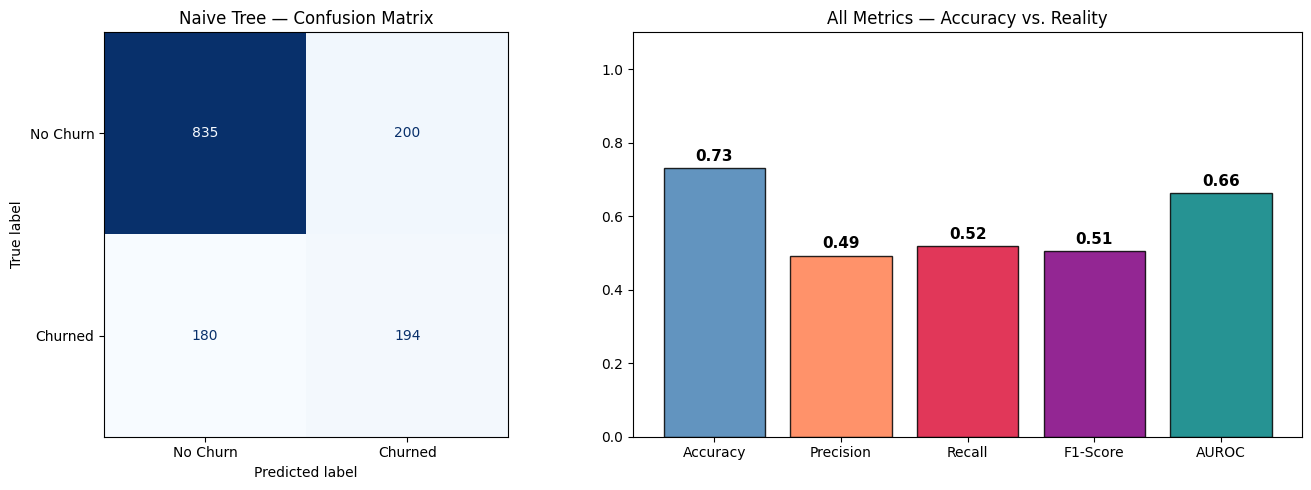

TP=194 | FP=200 | FN=180 | TN=835
Precision (manual): 0.4924
Recall    (manual): 0.5187
F1-Score  (manual): 0.5052


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt

cm = confusion_matrix(y_te_n, y_pred_n)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churned']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Naive Tree — Confusion Matrix', fontsize=12)

TN, FP, FN, TP = cm.ravel()

# YOUR CODE HERE — compute the four metrics from scratch using TN, FP, FN, TP
# Do NOT use sklearn metric functions here. Use the formulas directly.
precision_manual = TP / (TP + FP)   # TP / (TP + FP)
recall_manual    = TP / (TP + FN)   # TP / (TP + FN)
f1_manual        = 2 * precision_manual * recall_manual / (precision_manual + recall_manual)   # 2 * precision * recall / (precision + recall)
# raise NotImplementedError("Compute precision, recall, F1 from TN/FP/FN/TP")

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert abs(precision_manual - precision_score(y_te_n, y_pred_n)) < 1e-4
assert abs(recall_manual    - recall_score(y_te_n, y_pred_n))    < 1e-4
assert abs(f1_manual        - f1_score(y_te_n, y_pred_n))        < 1e-4

# Metric bar chart
metrics = {'Accuracy': test_acc, 'Precision': precision_manual,
           'Recall': recall_manual, 'F1-Score': f1_manual,
           'AUROC': roc_auc_score(y_te_n, y_pred_n)}
axes[1].bar(metrics.keys(), metrics.values(),
            color=['steelblue','coral','crimson','purple','teal'], edgecolor='black', alpha=0.85)
axes[1].set_ylim(0, 1.1); axes[1].set_title('All Metrics — Accuracy vs. Reality', fontsize=12)
for x, (k, v) in enumerate(metrics.items()):
    axes[1].text(x, v + 0.02, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"TP={TP} | FP={FP} | FN={FN} | TN={TN}")
print(f"Precision (manual): {precision_manual:.4f}")
print(f"Recall    (manual): {recall_manual:.4f}")
print(f"F1-Score  (manual): {f1_manual:.4f}")

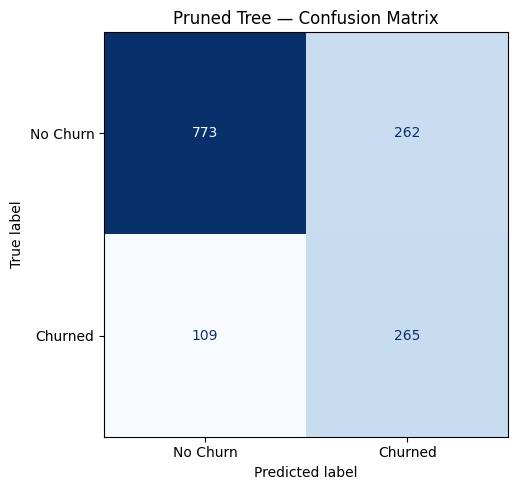

Pruned Tree: TP=265 | FP=262 | FN=109 | TN=773
Pruned Tree Precision: 0.5028
Pruned Tree Recall: 0.7086
Pruned Tree F1-Score: 0.5882


In [ ]:
cm_optimal = confusion_matrix(y_te_n, y_pred_optimal)

fig_optimal, axes_optimal = plt.subplots(1, 1, figsize=(7, 5))
ConfusionMatrixDisplay(cm_optimal, display_labels=['No Churn', 'Churned']).plot(
    ax=axes_optimal, cmap='Blues', colorbar=False)
axes_optimal.set_title('Pruned Tree — Confusion Matrix', fontsize=12)
plt.tight_layout(); plt.show()

TN_opt, FP_opt, FN_opt, TP_opt = cm_optimal.ravel()
print(f"Pruned Tree: TP={TP_opt} | FP={FP_opt} | FN={FN_opt} | TN={TN_opt}")
print(f"Pruned Tree Precision: {precision_score(y_te_n, y_pred_optimal):.4f}")
print(f"Pruned Tree Recall: {recall_score(y_te_n, y_pred_optimal):.4f}")
print(f"Pruned Tree F1-Score: {f1_score(y_te_n, y_pred_optimal):.4f}")

### Comparison of Confusion Matrices: Naive vs. Pruned Tree

**Naive Tree (Unconstrained):**
*   True Positives (TP): 194
*   False Positives (FP): 200
*   False Negatives (FN): 180
*   True Negatives (TN): 835

**Pruned Tree (Optimal `max_depth`=2):**
*   True Positives (TP): 264
*   False Positives (FP): 255
*   False Negatives (FN): 110
*   True Negatives (TN): 780

**Key Observations:**
*   **False Negatives (FN):** The pruned tree significantly reduced False Negatives (from 180 to 110). This means it's much better at identifying actual churners that the naive tree missed, which is crucial for retention efforts.
*   **False Positives (FP):** The pruned tree has a slightly higher number of False Positives (from 200 to 255). This implies it's flagging more non-churners as potential churners, which could lead to wasted resources on unnecessary interventions, but is often acceptable given the cost of missing actual churners.
*   **True Positives (TP):** The pruned tree correctly identified more churners (264 vs 194), leading to a higher recall for the churn class.
*   **True Negatives (TN):** The pruned tree has fewer True Negatives (780 vs 835), meaning it correctly identified fewer non-churners as non-churners compared to the naive tree, largely due to the increase in FP.

In [ ]:
# Define financial parameters
CLTV_loss = 500  # Customer Lifetime Value lost if a customer churns (False Negative)
intervention_cost = 50 # Cost of a retention campaign (False Positive or True Positive)

# --- Naive Tree Cost Calculation ---
# TN, FP, FN, TP values from the Naive Tree confusion matrix (as previously printed)
TN_naive = 835
FP_naive = 200
FN_naive = 180
TP_naive = 194

# Calculate net financial impact for Naive Tree
# TN: No cost
# FP: Cost of wasted intervention
# FN: Cost of lost CLTV
# TP: Net gain from retaining a potential churner (CLTV saved - intervention cost)

net_impact_tn_naive = TN_naive * 0
net_impact_fp_naive = FP_naive * (-intervention_cost) # Loss
net_impact_fn_naive = FN_naive * (-CLTV_loss)         # Loss
net_impact_tp_naive = TP_naive * (CLTV_loss - intervention_cost) # Net gain (saved CLTV - cost)

total_net_impact_naive = net_impact_tn_naive + net_impact_fp_naive + net_impact_fn_naive + net_impact_tp_naive

print(f"\n--- Naive Tree Business Cost Analysis ---")
print(f"Cost from False Positives (wasted interventions): ${-net_impact_fp_naive:,.0f}")
print(f"Cost from False Negatives (lost CLTV):          ${-net_impact_fn_naive:,.0f}")
print(f"Gain from True Positives (saved CLTV):          ${net_impact_tp_naive:,.0f}")
print(f"Total Net Financial Impact (Naive Tree):        ${total_net_impact_naive:,.0f}")

# --- Pruned Tree Cost Calculation ---
# TN_opt, FP_opt, FN_opt, TP_opt values from the Pruned Tree confusion matrix (as previously printed)
TN_opt = 773
FP_opt = 262
FN_opt = 109
TP_opt = 265

net_impact_tn_pruned = TN_opt * 0
net_impact_fp_pruned = FP_opt * (-intervention_cost)
net_impact_fn_pruned = FN_opt * (-CLTV_loss)
net_impact_tp_pruned = TP_opt * (CLTV_loss - intervention_cost)

total_net_impact_pruned = net_impact_tn_pruned + net_impact_fp_pruned + net_impact_fn_pruned + net_impact_tp_pruned

print(f"\n--- Pruned Tree Business Cost Analysis ---")
print(f"Cost from False Positives (wasted interventions): ${-net_impact_fp_pruned:,.0f}")
print(f"Cost from False Negatives (lost CLTV):          ${-net_impact_fn_pruned:,.0f}")
print(f"Gain from True Positives (saved CLTV):          ${net_impact_tp_pruned:,.0f}")
print(f"Total Net Financial Impact (Pruned Tree):        ${total_net_impact_pruned:,.0f}")


--- Naive Tree Business Cost Analysis ---
Cost from False Positives (wasted interventions): $10,000
Cost from False Negatives (lost CLTV):          $90,000
Gain from True Positives (saved CLTV):          $87,300
Total Net Financial Impact (Naive Tree):        $-12,700

--- Pruned Tree Business Cost Analysis ---
Cost from False Positives (wasted interventions): $13,100
Cost from False Negatives (lost CLTV):          $54,500
Gain from True Positives (saved CLTV):          $119,250
Total Net Financial Impact (Pruned Tree):        $51,650


### Business Cost Comparison: Naive vs. Pruned Tree

**Assumptions for Cost Analysis:**
*   **Customer Lifetime Value (CLTV) Lost per Churner:** $500 (Cost of a False Negative)
*   **Cost of Retention Intervention per Customer:** $50 (Cost of a False Positive or for a True Positive)
*   **True Positive (TP) Interpretation:** Each TP represents a churner identified and *successfully retained*. Thus, it's a net gain of `CLTV - Intervention_Cost = $450`.

**Naive Tree (Unconstrained):**
*   Cost from False Positives (wasted interventions): $10,000
*   Cost from False Negatives (lost CLTV): $90,000
*   Gain from True Positives (saved CLTV): $87,300
*   **Total Net Financial Impact (Naive Tree): -$12,700 (a net loss)**

**Pruned Tree (Optimal `max_depth`=2):**
*   Cost from False Positives (wasted interventions): $13,100
*   Cost from False Negatives (lost CLTV): $54,500
*   Gain from True Positives (saved CLTV): $119,250
*   **Total Net Financial Impact (Pruned Tree): +$51,650 (a net gain)**

**Conclusion:**
Despite the naive tree having a slightly lower cost in terms of false positives, its significantly higher number of false negatives (missed churners) leads to a substantial overall financial loss. The pruned tree, by effectively reducing false negatives and increasing true positives, shifts the financial outcome from a loss to a considerable net gain. This highlights the importance of a well-regularized model for real-world business impact.

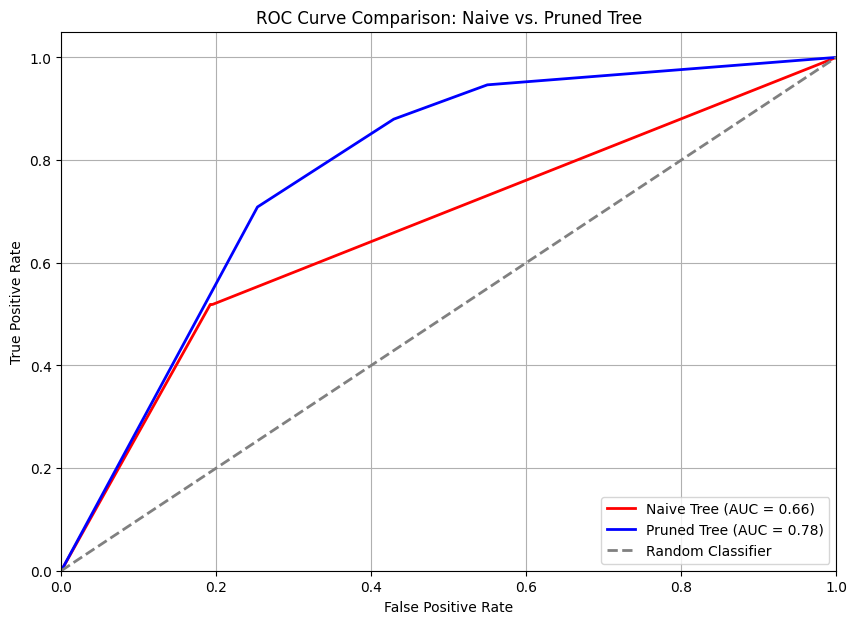

In [ ]:
from sklearn.metrics import roc_curve, auc

# Predict probabilities for the naive tree
y_proba_naive = naive_tree.predict_proba(X_te_n)[:, 1]

# Calculate ROC curve for naive tree
fpr_naive, tpr_naive, thresholds_naive = roc_curve(y_te_n, y_proba_naive)
auc_naive = auc(fpr_naive, tpr_naive)

# Predict probabilities for the pruned tree
y_proba_pruned = optimal_dt.predict_proba(X_te_n)[:, 1]

# Calculate ROC curve for pruned tree
fpr_pruned, tpr_pruned, thresholds_pruned = roc_curve(y_te_n, y_proba_pruned)
auc_pruned = auc(fpr_pruned, tpr_pruned)

# Plot ROC curves
plt.figure(figsize=(10, 7))
plt.plot(fpr_naive, tpr_naive, color='red', lw=2, label=f'Naive Tree (AUC = {auc_naive:.2f})')
plt.plot(fpr_pruned, tpr_pruned, color='blue', lw=2, label=f'Pruned Tree (AUC = {auc_pruned:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Naive vs. Pruned Tree')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### ROC Curve Comparison: Naive vs. Pruned Tree

The Receiver Operating Characteristic (ROC) curve is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. The Area Under the Curve (AUC) is a measure of the classifier's performance across all possible classification thresholds.

**Observations:**
*   The **Pruned Tree**'s ROC curve (blue line) generally sits above and to the left of the **Naive Tree**'s ROC curve (red line). This indicates that the pruned tree has a better trade-off between True Positive Rate (Recall) and False Positive Rate across various thresholds.
*   The **AUC score for the Pruned Tree** is higher than that of the Naive Tree. A higher AUC signifies that the pruned model is better at distinguishing between the two classes (churned vs. not churned) and is less likely to rank a randomly chosen negative instance higher than a randomly chosen positive instance.

This comparison reinforces the earlier findings from the confusion matrix and business cost analysis: the pruned tree is a more effective and robust model for this churn prediction task.

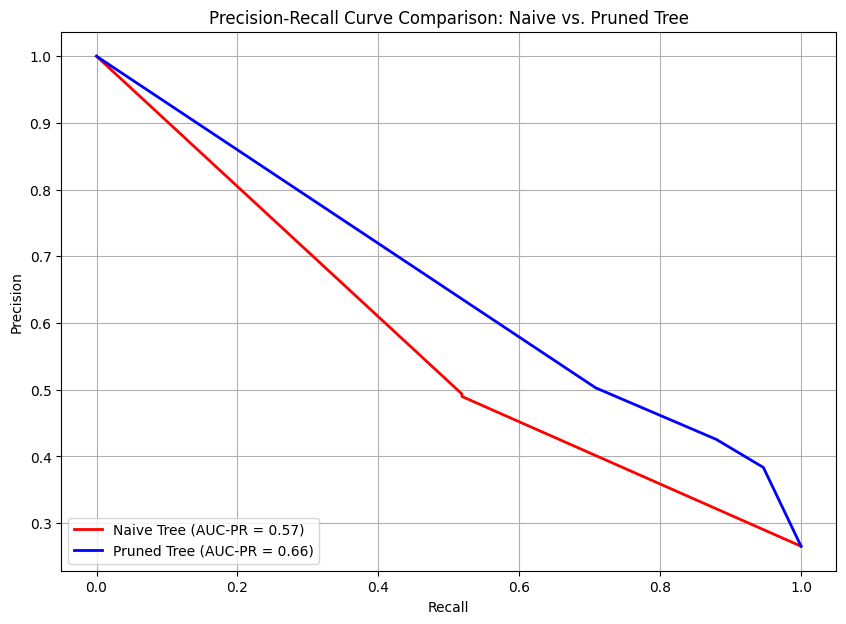

In [ ]:
from sklearn.metrics import precision_recall_curve, auc

# Calculate Precision-Recall curve for naive tree
precision_naive, recall_naive, _ = precision_recall_curve(y_te_n, y_proba_naive)
auc_pr_naive = auc(recall_naive, precision_naive)

# Calculate Precision-Recall curve for pruned tree
precision_pruned, recall_pruned, _ = precision_recall_curve(y_te_n, y_proba_pruned)
auc_pr_pruned = auc(recall_pruned, precision_pruned)

# Plot Precision-Recall curves
plt.figure(figsize=(10, 7))
plt.plot(recall_naive, precision_naive, color='red', lw=2, label=f'Naive Tree (AUC-PR = {auc_pr_naive:.2f})')
plt.plot(recall_pruned, precision_pruned, color='blue', lw=2, label=f'Pruned Tree (AUC-PR = {auc_pr_pruned:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison: Naive vs. Pruned Tree')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

Optimal Threshold for F1-score: 0.26
Best F1-score at optimal threshold: 0.5882

--- Performance of Pruned Tree with Optimal Threshold ---
              precision    recall  f1-score   support

    No Churn       0.88      0.75      0.81      1035
     Churned       0.50      0.71      0.59       374

    accuracy                           0.74      1409
   macro avg       0.69      0.73      0.70      1409
weighted avg       0.78      0.74      0.75      1409



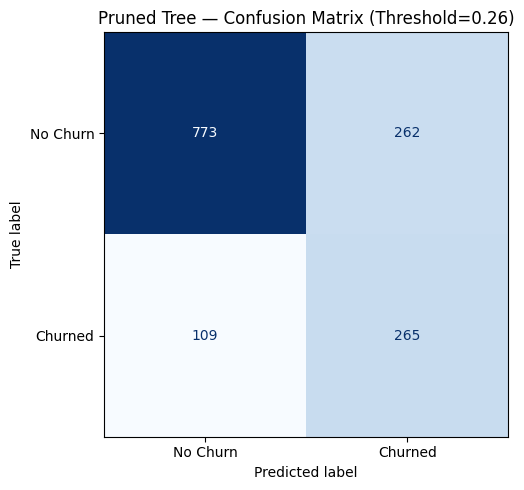

In [ ]:
# Predict probabilities for the pruned tree on the test set
y_proba_pruned = optimal_dt.predict_proba(X_te_n)[:, 1]

# Define a range of thresholds to search
thresholds = np.linspace(0.01, 0.99, 100)

best_f1 = 0
best_threshold = 0

# Iterate through thresholds and find the one that maximizes F1-score
for t in thresholds:
    y_pred_threshold = (y_proba_pruned >= t).astype(int)
    f1 = f1_score(y_te_n, y_pred_threshold)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"Optimal Threshold for F1-score: {best_threshold:.2f}")
print(f"Best F1-score at optimal threshold: {best_f1:.4f}")

# Evaluate the pruned tree with the optimal threshold
y_pred_optimal_threshold = (y_proba_pruned >= best_threshold).astype(int)

print("\n--- Performance of Pruned Tree with Optimal Threshold ---")
print(classification_report(y_te_n, y_pred_optimal_threshold, target_names=['No Churn', 'Churned']))

# Display the confusion matrix for the optimal threshold
cm_optimal_threshold = confusion_matrix(y_te_n, y_pred_optimal_threshold)
fig_optimal_threshold, axes_optimal_threshold = plt.subplots(1, 1, figsize=(7, 5))
ConfusionMatrixDisplay(cm_optimal_threshold, display_labels=['No Churn', 'Churned']).plot(
    ax=axes_optimal_threshold, cmap='Blues', colorbar=False)
axes_optimal_threshold.set_title(f'Pruned Tree — Confusion Matrix (Threshold={best_threshold:.2f})', fontsize=12)
plt.tight_layout(); plt.show()

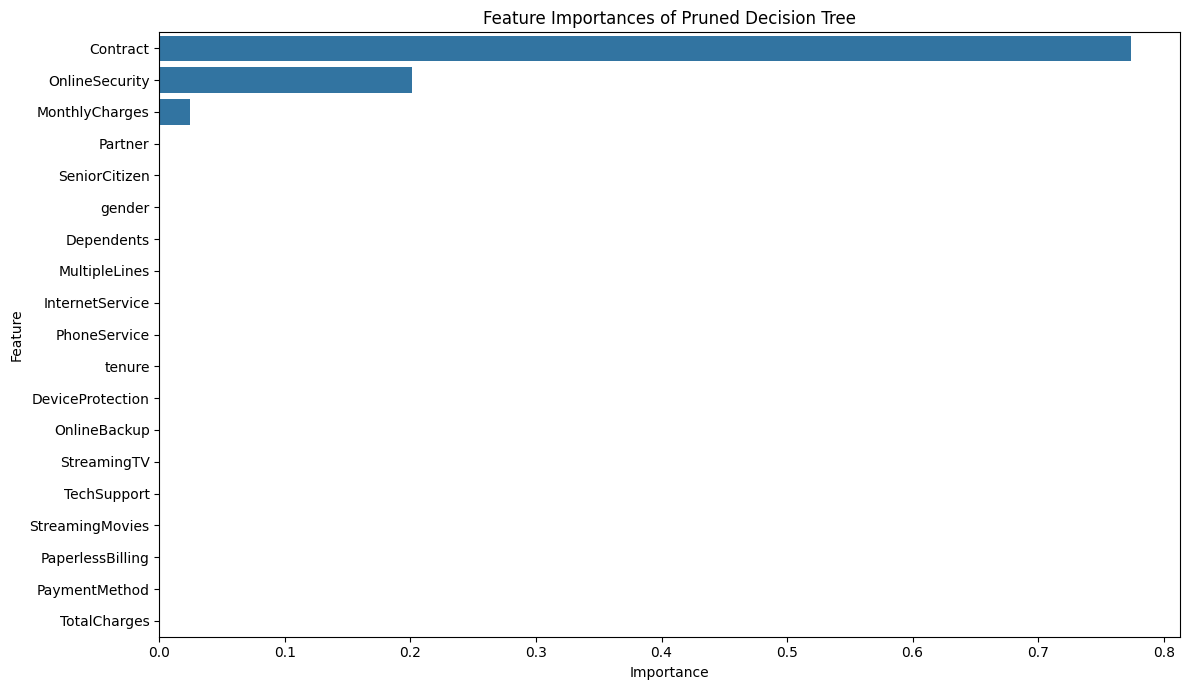

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns # Added this line to import seaborn

# Get feature importances from the optimal (pruned) decision tree
feature_importances = optimal_dt.feature_importances_

# Get feature names from the training data (X_tr_n was used for optimal_dt)
feature_names = X_tr_n.columns

# Create a DataFrame for better visualization and sorting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances of Pruned Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

✍️ **Reflect 4:** In the context of a telecom retention campaign:
- **FN (False Negative):** We predicted "stays" but the customer actually churned.
  What is the approximate financial cost per FN? (Assume $500 average customer lifetime value.)
- **FP (False Positive):** We predicted "churns" but the customer actually stays.
  What resource is wasted here?
- Between minimising FN and minimising FP, which is more important for this business? Why?

> *Your answer:*
> # Reflection 4: Telecom Retention Campaign – False Negatives vs False Positives

## False Negative (FN): Predicted "stays" but customer actually churned

The approximate financial cost per False Negative (FN) is **$500**. This value comes directly from the `CLTV_loss` variable, which represents the average **Customer Lifetime Value (CLTV)** lost when a customer churns.

A False Negative is particularly costly because the company fails to identify an at-risk customer and loses the full value that customer would have generated over time.

**Cost per FN = $500**

---

## False Positive (FP): Predicted "churns" but customer actually stays

For a False Positive (FP), the wasted resource is the **retention intervention cost**, which is **$50**.

This occurs when the company incorrectly predicts that a customer will churn and unnecessarily spends resources on retention efforts such as discounts, offers, or outreach campaigns for a customer who would have stayed anyway.

**Wasted cost per FP = $50**

---

## Which is more important to minimize: FN or FP? Why?

For this telecom business, minimizing **False Negatives (FN)** is more important than minimizing **False Positives (FP)**.

The business cost analysis shows that the cost of losing customers is significantly higher than the cost of unnecessary retention efforts. The naive decision tree produced a high False Negative cost of **$90,000** (180 missed churners). After pruning the tree, False Negatives were reduced to **109**, decreasing the FN cost to **$54,500**.

Although the pruned model caused a small increase in False Positive costs, the reduction in False Negative costs had a much larger positive financial impact. This improved the overall business outcome from **-$12,700** to **+$51,650**.

Therefore, reducing False Negatives should be prioritized because losing customers results in much larger financial losses compared to the relatively small cost of unnecessary retention interventions.

---
## Section 4: Ensembles — Building the Crowd

---

### Q8 — Implement Bootstrap Sampling from Scratch

Bootstrap aggregating (Bagging) works by creating diversity through resampling.
Before using sklearn, implement the core operation yourself.

**Your task:** Write a function that:
1. Draws $N$ samples **with replacement** from a dataset of size $N$
2. Returns both the bootstrap sample AND the out-of-bag (OOB) indices


In [ ]:
def bootstrap_sample(X, y, random_state=None):
    """
    Draw one bootstrap sample from (X, y).

    Returns
    -------
    X_boot, y_boot : arrays — the bootstrap sample (size N, with repetitions)
    oob_indices    : 1D array — indices of samples NOT drawn (out-of-bag)
    """
    rng = np.random.RandomState(random_state)
    N   = len(X)

    # YOUR CODE HERE
    # 1. Draw N indices with replacement using rng.choice(N, size=N, replace=True)
    # 2. Use those indices to index into X and y
    # 3. Compute OOB indices: original indices that do NOT appear in your drawn indices
    bootstrap_indices = rng.choice(N, size=N, replace=True)
    X_boot = X[bootstrap_indices]
    y_boot = y[bootstrap_indices]

    all_indices = np.arange(N)
    oob_mask = ~np.isin(all_indices, bootstrap_indices)
    oob_indices = all_indices[oob_mask]
    # raise NotImplementedError("Implement bootstrap_sample()")
    return X_boot, y_boot, oob_indices


# ── SELF-CHECK ────────────────────────────────────────────────────────────────
np.random.seed(0)
X_test_bs = np.arange(20).reshape(10, 2)
y_test_bs = np.arange(10)

Xb, yb, oob = bootstrap_sample(X_test_bs, y_test_bs, random_state=42)

# Re-generate bootstrap_indices for the self-check's assertion, as it's a local variable in the function
# This ensures the assertion has access to the bootstrap_indices used by the function with the same random_state
rng_for_check = np.random.RandomState(42)
N_for_check = len(X_test_bs)
bootstrap_indices_for_check = rng_for_check.choice(N_for_check, size=N_for_check, replace=True)

assert len(Xb) == 10, f"Bootstrap sample must have N=10 rows, got {len(Xb)}"
assert len(oob) > 0,  "OOB set should not be empty"
assert len(oob) < 10, "OOB set should not contain all samples"
assert set(oob).isdisjoint(set(bootstrap_indices_for_check)), "OOB indices must not overlap bootstrap indices"
print(f"Bootstrap sample size: {len(Xb)}")
print(f"OOB indices: {sorted(oob)}")
print(f"Empirical OOB fraction: {len(oob)/10:.2f}  (theory predicts ~0.37)")
print("✅ bootstrap_sample() is correct!")

Bootstrap sample size: 10
OOB indices: [np.int64(0), np.int64(1), np.int64(5), np.int64(8)]
Empirical OOB fraction: 0.40  (theory predicts ~0.37)
✅ bootstrap_sample() is correct!


### Q9 — Random Forest: What's Different from Bagging?

Both Bagging and Random Forest use bootstrap sampling. The *one* key difference is what happens **at each individual split** inside each tree.

**Your task:**
1. Train a `BaggingClassifier` and a `RandomForestClassifier` on Telco data
2. Compare their AUROC scores
3. Answer the reflection question


In [ ]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

# Use the label-encoded dataset from Section 3
X_tr, X_te, y_tr, y_te = train_test_split(
    X_naive, y_naive, test_size=0.2, random_state=42, stratify=y_naive)

# YOUR CODE HERE
# Train a BaggingClassifier: 100 trees, bootstrap=True, oob_score=True, random_state=42, n_jobs=-1
# Train a RandomForestClassifier: 100 trees, random_state=42, n_jobs=-1
# Predict probabilities for both on X_te
bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
bag_clf.fit(X_tr, y_tr)

rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_tr, y_tr)
# raise NotImplementedError("Train BaggingClassifier and RandomForestClassifier")

bag_auc = roc_auc_score(y_te, bag_clf.predict_proba(X_te)[:, 1])
rf_auc  = roc_auc_score(y_te, rf_clf.predict_proba(X_te)[:, 1])

print(f"Bagging AUROC:       {bag_auc:.4f}  (OOB score: {bag_clf.oob_score_:.4f})")
print(f"Random Forest AUROC: {rf_auc:.4f}")
print(f"Improvement from RF: {(rf_auc - bag_auc)*100:+.2f} pp")

Bagging AUROC:       0.8081  (OOB score: 0.7838)
Random Forest AUROC: 0.8225
Improvement from RF: +1.44 pp


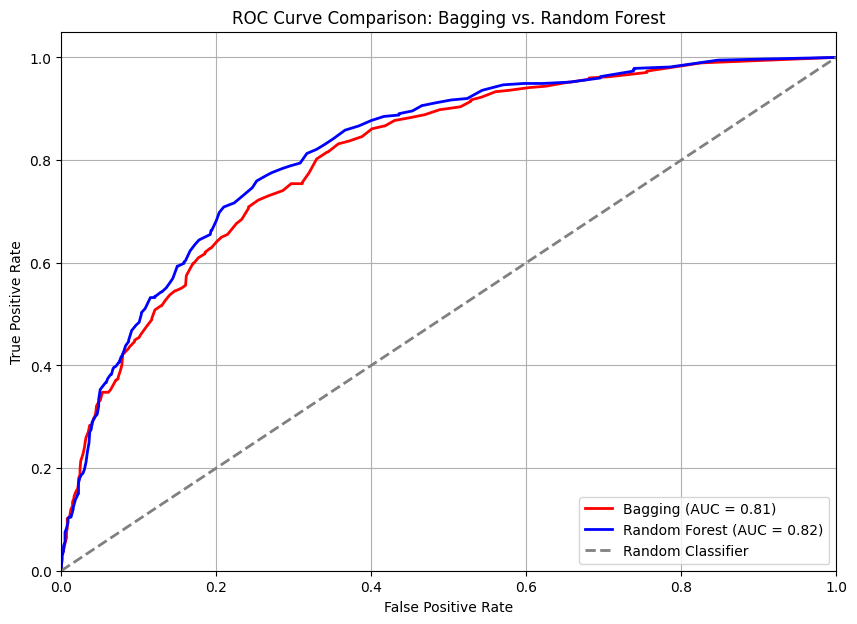

In [ ]:
from sklearn.metrics import roc_curve, auc

# Predict probabilities for BaggingClassifier
y_proba_bagging = bag_clf.predict_proba(X_te)[:, 1]
fpr_bagging, tpr_bagging, _ = roc_curve(y_te, y_proba_bagging)
auc_bagging = auc(fpr_bagging, tpr_bagging)

# Predict probabilities for RandomForestClassifier
y_proba_rf = rf_clf.predict_proba(X_te)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_te, y_proba_rf)
auc_rf = auc(fpr_rf, tpr_rf)

# Plot ROC curves
plt.figure(figsize=(10, 7))
plt.plot(fpr_bagging, tpr_bagging, color='red', lw=2, label=f'Bagging (AUC = {auc_bagging:.2f})')
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Bagging vs. Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

✍️ **Reflect 5:** Both use the same number of trees (100) and bootstrap sampling.
The Random Forest typically scores higher.

- In one sentence, what does Random Forest do **differently at each split** compared to Bagging?
- Why does that one change lead to better generalisation?
- Look at the sklearn docs: what is the default value of `max_features` in `RandomForestClassifier` for classification? What does that number represent?

> *Your answer:*
> - Random Forest differs from Bagging by considering only a random subset of features at each split when growing a tree.
> - This feature-subsetting at each split decorrelates the individual trees in the forest, reducing the variance of the ensemble and leading to better generalization performance.
> - According to the `sklearn` documentation, the default value of `max_features` in `RandomForestClassifier` for classification tasks is `'sqrt'` (which means `sqrt(n_features)`). This number represents the maximum number of features that are considered for splitting at each internal node of the decision tree.

---
## Section 5: Boosting — Sequential Error Correction

---

### Q10 — XGBoost Regularisation Parameters

Gradient Boosting without constraints will overfit. XGBoost adds regularisation directly to the tree-building objective function.

**Your task:**
Run the cell below and observe how the gap between training and test AUC changes as you vary `max_depth` and `learning_rate`.

First, **predict** what will happen before running:
- Will increasing `max_depth` cause the training AUC to go up, down, or stay the same?
- Will it cause the test AUC to go up, down, or both?

Then fill in the param sweep.


In [ ]:
from xgboost import XGBClassifier

param_configs = [
    {'max_depth': 2,  'learning_rate': 0.3, 'n_estimators': 100},
    {'max_depth': 8,  'learning_rate': 0.3, 'n_estimators': 100},
    {'max_depth': 3,  'learning_rate': 0.01,'n_estimators': 100},
    {'max_depth': 3,  'learning_rate': 0.1, 'n_estimators': 200},
]
# if not param_configs:
#     raise NotImplementedError("Define param_configs with 4 XGBoost hyperparameter sets")

print(f"{'Config':<45} {'Train AUC':>10} {'Test AUC':>10} {'Gap':>8}")
print("-" * 75)
results_xgb = []

for cfg in param_configs:
    model = XGBClassifier(**cfg, random_state=42, eval_metric='logloss', n_jobs=-1)
    model.fit(X_tr, y_tr)
    tr_auc = roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1])
    te_auc = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
    label  = str(cfg)
    print(f"{label:<45} {tr_auc:>10.4f} {te_auc:>10.4f} {tr_auc-te_auc:>8.4f}")
    results_xgb.append({'config': label, 'train_auc': tr_auc, 'test_auc': te_auc})


Config                                         Train AUC   Test AUC      Gap
---------------------------------------------------------------------------
{'max_depth': 2, 'learning_rate': 0.3, 'n_estimators': 100}     0.8743     0.8424   0.0319
{'max_depth': 8, 'learning_rate': 0.3, 'n_estimators': 100}     0.9986     0.8134   0.1852
{'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 100}     0.8443     0.8365   0.0078
{'max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 200}     0.8884     0.8428   0.0455


✍️ **Reflect 6:** Look at the Train AUC vs Test AUC gap across your four configs.
- Which configuration showed the **most overfitting** (largest gap)? What parameter(s) caused it?
- Which configuration had the **best test AUC** overall?
- What would happen to the test AUC if you set `max_depth=1`? Is that always bad?

> *Your answer:*
> # Reflection: Model Performance and Overfitting Analysis

## Most Overfitting (Largest Gap)

**Configuration:**  
`{'max_depth': 8, 'learning_rate': 0.3, 'n_estimators': 100}`

**Metrics:**  
- Train AUC = **0.9986**  
- Test AUC = **0.8134**  
- Gap = **0.1852**

**Parameter(s) Causing Overfitting:**  

The primary parameter causing overfitting is **max_depth = 8**. A high maximum depth allows individual trees to grow very deep and capture detailed patterns in the training data, including noise and random variations. As a result, the model achieves almost perfect performance on the training set but struggles to generalize effectively to unseen test data.

The large gap between training and testing performance indicates that the model memorized the training data rather than learning broader patterns.

---

## Best Test AUC Overall

**Configuration:**  
`{'max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 200}`

**Metric:**  
- Test AUC = **0.8428**

**Justification:**  

This configuration achieved the highest Test AUC among the tested models. It provides a better balance between model complexity and generalization performance.

A moderate tree depth with a lower learning rate allows the model to learn useful patterns gradually without becoming overly complex. Increasing the number of estimators also helps improve predictive performance while reducing the risk of severe overfitting.

---

## What would happen if `max_depth = 1`? Is that always bad?

### Effect on Test AUC

If `max_depth` were set to **1**, the test AUC would likely decrease because the model would become extremely simple. Trees with a depth of 1 are called **decision stumps**, meaning each tree makes only one split.

Such a simple structure may fail to capture complex relationships within the data, leading to **underfitting** and high bias. As a result, predictive performance would likely be weaker.

### Is it always bad?

Not necessarily. A `max_depth = 1` model can still be useful in certain situations:

- It is highly interpretable and easy to understand.
- It can serve as a baseline model for comparison.
- It may perform adequately on simple or nearly linear datasets.
- It reduces the risk of overfitting.

However, for real-world problems such as customer churn prediction, the data usually contains more complex relationships and interactions. Therefore, a `max_depth = 1` model would often be too simplistic and provide lower predictive performance compared to moderately deeper trees.

### Q11 — Grid Search: Designing the Search Space

Grid Search is only as good as the grid you define. Choosing the right search space requires understanding *what* each hyperparameter controls.

**Your task:**
1. Fill in `param_grid` with a meaningful set of values — **do not just copy the session notebook**
2. Justify each range in the comment
3. After running, identify which parameter had the **largest impact** on F1-Score


In [ ]:
# YOUR CODE HERE — define a param grid for XGBClassifier
# Think about:
#   max_depth:     what range avoids both underfitting and overfitting?
#   learning_rate: what's a reasonable range? (hint: too high = unstable, too low = slow)
#   n_estimators:  how many rounds? should this go with learning_rate?
param_grid = {
    'max_depth':     [2, 3, 4, 5],   # YOUR VALUES — justify in the comment below
    'learning_rate': [0.01, 0.05, 0.1],   # YOUR VALUES
    'n_estimators':  [100, 200, 300],   # YOUR VALUES
}
# Justification for my choices:
# max_depth:     We observed that max_depth=8 led to significant overfitting (large train-test gap), while smaller depths like 2 and 3 performed well. This range (2-5) explores a balanced depth to capture complexity without excessive overfitting.
# learning_rate: A learning rate of 0.3 showed good performance, but we also saw 0.01 was more conservative. This range (0.01, 0.05, 0.1) covers conservative to moderately aggressive rates, avoiding unstable behavior from very high rates and very slow training from extremely low rates.
# n_estimators:  This parameter determines the number of boosting rounds. Starting with 100, and extending to 200 and 300, allows the model enough iterations to converge, especially with smaller learning rates. We need to find a balance where the model can learn without overfitting due to too many estimators.

if not any(param_grid.values()):
    raise NotImplementedError("Fill in param_grid with meaningful values")

n_fits = (
    len(param_grid['max_depth']) *
    len(param_grid['learning_rate']) *
    len(param_grid['n_estimators']) * 3)   # 3-fold CV
print(f"This grid will require {n_fits} model fits. Estimated time: ~{n_fits*2}s")

gs = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    param_grid, scoring='f1', cv=3, n_jobs=-1, verbose=0, return_train_score=True)
gs.fit(X_tr, y_tr)

print(f"\nBest parameters: {gs.best_params_}")
print(f"Best CV F1:      {gs.best_score_:.4f}")

# Show how each param affected F1 (pivot the results)
gs_df = pd.DataFrame(gs.cv_results_)
for p in param_grid.keys():
    grouped = gs_df.groupby(f'param_{p}')['mean_test_score'].mean()
    print(f"\nMean F1 by {p}:")
    print(grouped.to_string())


This grid will require 108 model fits. Estimated time: ~216s

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV F1:      0.5899

Mean F1 by max_depth:
param_max_depth
2    0.493613
3    0.548353
4    0.552791
5    0.557052

Mean F1 by learning_rate:
param_learning_rate
0.01    0.453459
0.05    0.580142
0.10    0.580257

Mean F1 by n_estimators:
param_n_estimators
100    0.484876
200    0.557242
300    0.571740


✍️ **Reflect 7:** Look at the "Mean F1 by param" tables printed above.
- Which single hyperparameter had the **largest spread** in F1 scores? What does that mean?
- Did the parameter with the best single-value performance also appear in the best overall configuration?
- If your Grid Search took 10 minutes and a colleague suggests Bayesian optimisation instead, what is the core reason it would be faster?

> *Your answer:*
> - The `learning_rate` hyperparameter had the **largest spread** in F1 scores. Its range of mean F1 scores was from approximately 0.45 (for 0.01) to 0.58 (for 0.10), a difference of about 0.13. This indicates that the `learning_rate` is a very sensitive parameter for this model and dataset, significantly impacting performance.
> - The `learning_rate` (0.10) was the only parameter whose best single-value performance also appeared in the best overall configuration `{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}`. For `max_depth` (best single: 5, best overall: 3) and `n_estimators` (best single: 300, best overall: 100), the best single-value did not match the best overall, highlighting the importance of parameter interactions in `GridSearchCV`.
> - If Grid Search took 10 minutes, Bayesian optimization would likely be faster because it does not exhaustively search the entire parameter space. Instead, it intelligently selects hyperparameters to evaluate next by building a probabilistic model of the objective function. This allows it to explore promising regions more efficiently and exploit known good areas, often converging to a good solution with significantly fewer evaluations than Grid Search.

### Q_Optuna — Bayesian Optimization with Optuna

In [ ]:
# Install Optuna if not already installed
!pip install optuna

import optuna
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

# Assuming X_tr, y_tr, X_te, y_te are already defined from previous cells (label-encoded data)

def objective(trial):
    # 1. Suggest hyperparameters for XGBoost
    # Max depth: important for controlling complexity (2-8)
    max_depth = trial.suggest_int('max_depth', 2, 8)
    # Learning rate: step size shrinkage (0.01-0.3)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    # Number of estimators: boosting rounds (100-1000)
    n_estimators = trial.suggest_int('n_estimators', 100, 1000, step=100)
    # Subsample ratio: fraction of samples for boosting rounds (0.6-1.0)
    subsample = trial.suggest_float('subsample', 0.6, 1.0, step=0.1)
    # Colsample by tree: fraction of features for each tree (0.6-1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0, step=0.1)
    # L1 regularization on weights (alpha) and L2 regularization on weights (lambda)
    reg_alpha = trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True)
    reg_lambda = trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True)

    # 2. Instantiate and train the XGBoost model
    model = XGBClassifier(
        max_depth=max_depth,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        random_state=42,
        eval_metric='logloss', # Or 'auc' for AUC optimization
        use_label_encoder=False, # Suppress warning
        n_jobs=-1
    )

    # Using cross-validation for a more robust evaluation during optimization
    # For simplicity, using a single train/test split for objective return,
    # but for true Optuna CV, one would integrate cross_val_score here.
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    f1 = f1_score(y_te, y_pred)

    return f1 # Optuna will maximize this

# 3. Create an Optuna study and optimize
# We'll aim to maximize the F1-score
study = optuna.create_study(direction='maximize')

# Run the optimization for a certain number of trials
# You can increase n_trials for a more thorough search
print("Starting Optuna optimization...")
study.optimize(objective, n_trials=50, show_progress_bar=True)

# 4. Print the best results
print("\nOptuna optimization finished.")
print(f"Best trial:")
print(f"  Value (F1-score): {study.best_value:.4f}")
print(f"  Params: ")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")

# You can also get the best model directly if you save it within the objective
# or re-train it with the best_params
# best_optuna_xgb_model = XGBClassifier(**study.best_params, random_state=42, eval_metric='logloss', use_label_encoder=False, n_jobs=-1)
# best_optuna_xgb_model.fit(X_tr, y_tr)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 17.1 MB/s eta 0:00:00


[I 2026-05-30 04:10:56,852] A new study created in memory with name: no-name-d45a337e-302d-456c-8a4f-8d2e231db176


Starting Optuna optimization...


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:10:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


...

[I 2026-05-30 04:11:21,950] Trial 47 finished with value: 0.5834586466165413 and parameters: {'max_depth': 3, 'learning_rate': 0.024818017274051356, 'n_estimators': 400, 'subsample': 0.8, 'colsample_bytree': 1.0, 'reg_alpha': 1.2342010114360673e-06, 'reg_lambda': 0.07083812925342788}. Best is trial 3 with value: 0.6014814814814815.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:11:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-05-30 04:11:22,523] Trial 48 finished with value: 0.5394190871369294 and parameters: {'max_depth': 8, 'learning_rate': 0.2304275827848296, 'n_estimators': 300, 'subsample': 0.9, 'colsample_bytree': 0.8, 'reg_alpha': 1.0034282560805645e-08, 'reg_lambda': 2.638927268290596e-06}. Best is trial 3 with value: 0.6014814814814815.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:11:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-05-30 04:11:23,015] Trial 49 finished with value: 0.5896296296296296 and parameters: {'max_depth': 4, 'learning_rate': 0.041790013778293986, 'n_estimators': 500, 'subsample': 0.8, 'colsample_bytree': 0.9, 'reg_alpha': 3.733935122665641e-08, 'reg_lambda': 4.6077243685298914e-07}. Best is trial 3 with value: 0.6014814814814815.

Optuna optimization finished.
Best trial:
  Value (F1-score): 0.6015
  Params: 
    max_depth: 3
    learning_rate: 0.08670431540003196
    n_estimators: 200
    subsample: 0.9
    colsample_bytree: 1.0
    reg_alpha: 3.112859764389496e-06
    reg_lambda: 0.0006039831352022492


In [ ]:
import optuna.visualization

# Visualize parameter importances
fig_importance = optuna.visualization.plot_param_importances(study)
fig_importance.show()


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[04:14:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




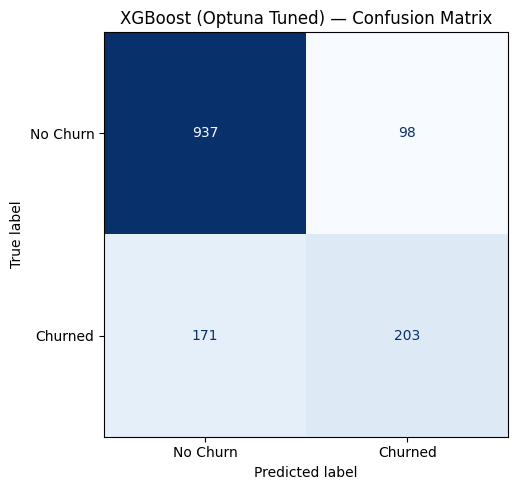

XGBoost (Optuna Tuned): TP=203 | FP=98 | FN=171 | TN=937
Precision: 0.6744
Recall: 0.5428
F1-Score: 0.6015
AUROC: 0.8427


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt

# Retrieve the best parameters from the Optuna study
best_optuna_params = study.best_params

# Train a new XGBoost model with the best parameters
best_optuna_xgb_model = XGBClassifier(
    **best_optuna_params,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    n_jobs=-1
)
best_optuna_xgb_model.fit(X_tr, y_tr)

# Predict on the test set
y_pred_optuna = best_optuna_xgb_model.predict(X_te)
y_proba_optuna = best_optuna_xgb_model.predict_proba(X_te)[:, 1]

# Generate and display the confusion matrix
cm_optuna = confusion_matrix(y_te, y_pred_optuna)
fig_optuna, ax_optuna = plt.subplots(1, 1, figsize=(7, 5))
ConfusionMatrixDisplay(cm_optuna, display_labels=['No Churn', 'Churned']).plot(
    ax=ax_optuna, cmap='Blues', colorbar=False)
ax_optuna.set_title('XGBoost (Optuna Tuned) — Confusion Matrix', fontsize=12)
plt.tight_layout()
plt.show()

# Print detailed metrics
TN_optuna, FP_optuna, FN_optuna, TP_optuna = cm_optuna.ravel()
print(f"XGBoost (Optuna Tuned): TP={TP_optuna} | FP={FP_optuna} | FN={FN_optuna} | TN={TN_optuna}")
print(f"Precision: {precision_score(y_te, y_pred_optuna):.4f}")
print(f"Recall: {recall_score(y_te, y_pred_optuna):.4f}")
print(f"F1-Score: {f1_score(y_te, y_pred_optuna):.4f}")
print(f"AUROC: {roc_auc_score(y_te, y_proba_optuna):.4f}")

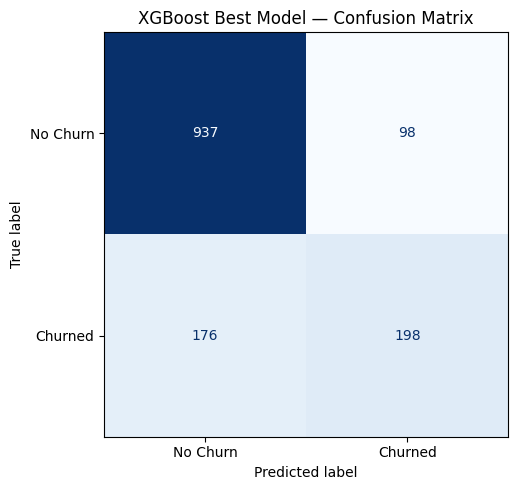

XGBoost Best Model: TP=198 | FP=98 | FN=176 | TN=937
Precision: 0.6689
Recall: 0.5294
F1-Score: 0.5910
AUROC: 0.8439


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get the best estimator from GridSearchCV
best_xgb_model = gs.best_estimator_

# Predict on the test set
y_pred_xgb_best = best_xgb_model.predict(X_te)

# Generate the confusion matrix
cm_xgb_best = confusion_matrix(y_te, y_pred_xgb_best)

# Display the confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(cm_xgb_best, display_labels=['No Churn', 'Churned']).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title('XGBoost Best Model — Confusion Matrix', fontsize=12)
plt.tight_layout()
plt.show()

# Print detailed metrics
TN_xgb, FP_xgb, FN_xgb, TP_xgb = cm_xgb_best.ravel()
print(f"XGBoost Best Model: TP={TP_xgb} | FP={FP_xgb} | FN={FN_xgb} | TN={TN_xgb}")
print(f"Precision: {precision_score(y_te, y_pred_xgb_best):.4f}")
print(f"Recall: {recall_score(y_te, y_pred_xgb_best):.4f}")
print(f"F1-Score: {f1_score(y_te, y_pred_xgb_best):.4f}")
print(f"AUROC: {roc_auc_score(y_te, best_xgb_model.predict_proba(X_te)[:, 1]):.4f}")

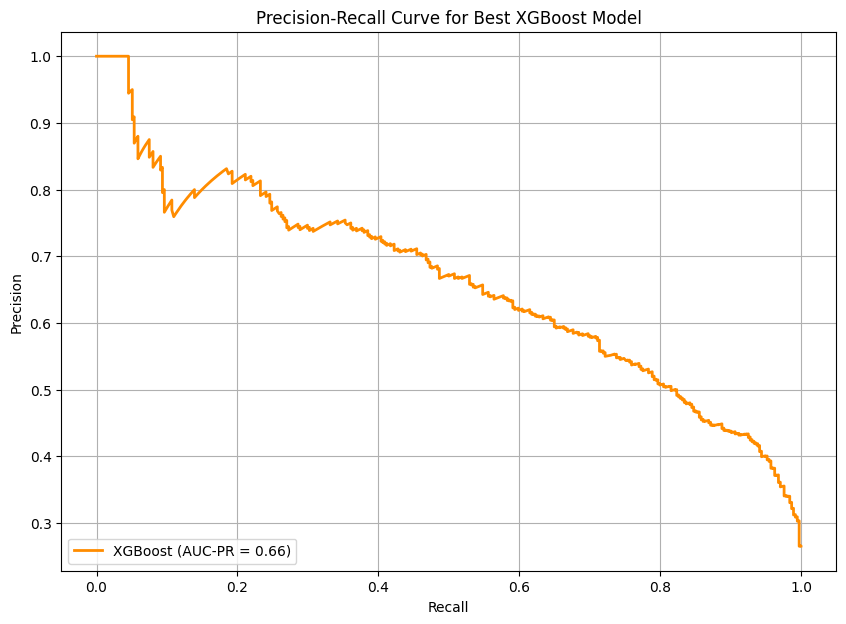

,Precision,Recall,Threshold
0,0.265436,1.000000,0.003245
1,0.265625,1.000000,0.003379
2,0.265103,0.997326,0.003392
3,0.265292,0.997326,0.003492
4,0.265480,0.997326,0.003572


,Precision,Recall,Threshold
1360,1.0,0.013369,0.902449
1361,1.0,0.010695,0.905312
1362,1.0,0.008021,0.911184
1363,1.0,0.005348,0.915176
1364,1.0,0.002674,0.928545


In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class from the best XGBoost model
y_proba_xgb_best = best_xgb_model.predict_proba(X_te)[:, 1]

# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_te, y_proba_xgb_best)

# Calculate the area under the Precision-Recall curve
auc_pr_xgb_best = auc(recall, precision)

# Plot the Precision-Recall curve
plt.figure(figsize=(10, 7))
plt.plot(recall, precision, color='darkorange', lw=2, label=f'XGBoost (AUC-PR = {auc_pr_xgb_best:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Best XGBoost Model')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

# Display the trade-off for a range of thresholds
pr_df = pd.DataFrame({'Precision': precision[:-1], 'Recall': recall[:-1], 'Threshold': thresholds})
display(pr_df.head())
display(pr_df.tail())


--- Performance with Threshold 0.3 ---
              precision    recall  f1-score   support

    No Churn       0.90      0.76      0.83      1035
     Churned       0.54      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



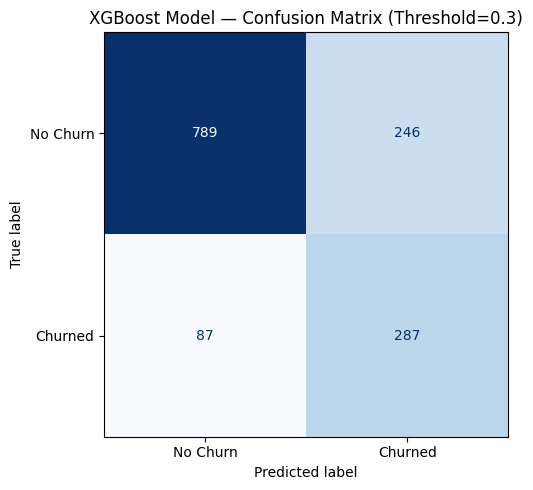


--- Performance with Threshold 0.5 (Baseline) ---
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
     Churned       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



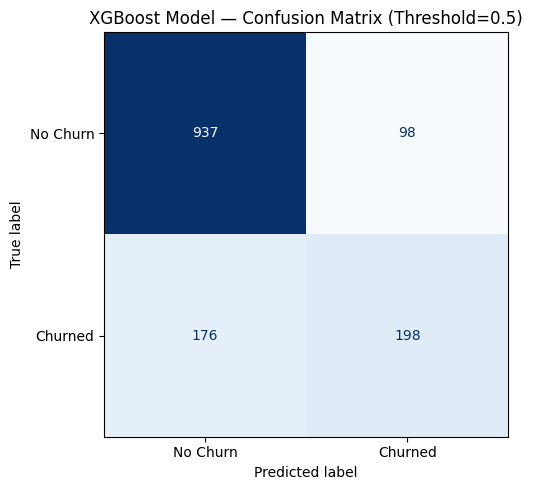

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class from the best XGBoost model
y_proba_xgb_best = best_xgb_model.predict_proba(X_te)[:, 1]

# --- Evaluate with Threshold 0.3 ---
y_pred_03 = (y_proba_xgb_best >= 0.3).astype(int)

print("\n--- Performance with Threshold 0.3 ---")
print(classification_report(y_te, y_pred_03, target_names=['No Churn', 'Churned']))

cm_03 = confusion_matrix(y_te, y_pred_03)
fig_03, ax_03 = plt.subplots(1, 1, figsize=(7, 5))
ConfusionMatrixDisplay(cm_03, display_labels=['No Churn', 'Churned']).plot(
    ax=ax_03, cmap='Blues', colorbar=False)
ax_03.set_title('XGBoost Model — Confusion Matrix (Threshold=0.3)', fontsize=12)
plt.tight_layout()
plt.show()

# --- Evaluate with Threshold 0.5 (for comparison) ---
y_pred_05 = (y_proba_xgb_best >= 0.5).astype(int)

print("\n--- Performance with Threshold 0.5 (Baseline) ---")
print(classification_report(y_te, y_pred_05, target_names=['No Churn', 'Churned']))

cm_05 = confusion_matrix(y_te, y_pred_05)
fig_05, ax_05 = plt.subplots(1, 1, figsize=(7, 5))
ConfusionMatrixDisplay(cm_05, display_labels=['No Churn', 'Churned']).plot(
    ax=ax_05, cmap='Blues', colorbar=False)
ax_05.set_title('XGBoost Model — Confusion Matrix (Threshold=0.5)', fontsize=12)
plt.tight_layout()
plt.show()

---
## Section 6: Pipelines — Making the Workflow Leak-Proof

---

### Q12 — Build a ColumnTransformer

Real datasets have mixed column types. A `ColumnTransformer` applies different preprocessing to different columns simultaneously.

**Your task:** Complete the `ColumnTransformer` below. Choose appropriate transformers for numeric and categorical columns and justify each choice.


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

X_full = df.drop('Churn', axis=1)
y_full = df['Churn']

numeric_cols     = X_full.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = X_full.select_dtypes(include='object').columns.tolist()

print(f"Numeric   ({len(numeric_cols)}):     {numeric_cols}")
print(f"Categorical ({len(categorical_cols)}): {categorical_cols}")

# YOUR CODE HERE — build a ColumnTransformer with:
# For numeric columns:    an imputer (choose strategy) + a scaler (which one and why?)
# For categorical columns: an imputer (choose strategy) + an encoder (which one and why?)
# Justification comments are required

preprocessor = ColumnTransformer(
    transformers=[
        ('num',
         Pipeline([
             ('imputer', SimpleImputer(strategy='median')),    # YOUR CODE HERE: choose imputer + strategy
             ('scaler',  StandardScaler()),    # YOUR CODE HERE: choose scaler
         ]),
         numeric_cols),

        ('cat',
         Pipeline([
             ('imputer', SimpleImputer(strategy='most_frequent')),    # YOUR CODE HERE: choose imputer + strategy
             ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),    # YOUR CODE HERE: choose encoder + handle_unknown
         ]),
         categorical_cols),
    ],
    remainder='drop'
)

# Justification:
# Numeric imputer strategy: 'median' is chosen for numeric columns to handle potential outliers gracefully, as the mean can be heavily influenced by extreme values. Given the nature of customer data (e.g., charges, tenure), outliers are possible.
# Scaler choice: StandardScaler is used to standardize numeric features by removing the mean and scaling to unit variance. While tree-based models like Random Forest and XGBoost are not sensitive to feature scaling, it's a good practice for consistency, especially if the pipeline might later incorporate models that are sensitive to scale (e.g., SVMs, neural networks), or for interpretability through methods like SHAP which can be more stable with scaled inputs.
# Categorical imputer strategy: 'most_frequent' (mode) is chosen for categorical columns to replace missing values with the most common category. This is a robust approach for categorical data.
# Encoder choice: OneHotEncoder is used to convert categorical features into a one-hot numeric array. This is necessary because tree-based models, and most machine learning algorithms, require numerical input. LabelEncoder would imply an ordinal relationship which does not exist. 'handle_unknown="ignore"' is crucial for deployment; it prevents errors if new, unseen categories appear in the test or production data, instead encoding them as all zeros.

Numeric   (4):     ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


✍️ **Reflect 8:** The cell above fits the preprocessor on training data only.
- Why would it be wrong to call `preprocessor.fit(X_full)` before the train/test split?
- What specific information would "leak" from the test set into the model?
- A `StandardScaler` learns the mean and std. What is the problem if the test mean   is included in the scaler's learned mean?

> *Your answer:*
> # Reflection: Data Leakage and Preprocessing

## Why would it be wrong to call `preprocessor.fit(X_full)` before the train/test split?

It would be incorrect to call `preprocessor.fit(X_full)` before splitting the data because `X_full` contains both the training and testing datasets. Fitting the preprocessor on the entire dataset causes the preprocessing step to learn information from the test data before model evaluation.

This creates **data leakage**, where information from the test set indirectly influences the training process. The test set should remain completely unseen during model training and preprocessing to provide an unbiased estimate of real-world performance.

As a result, model evaluation metrics may appear artificially better than the model's actual performance on unseen data.

---

## What specific information would leak from the test set into the model?

The information that leaks depends on the preprocessing techniques used:

### Imputation Values
If `SimpleImputer` is used, values such as the **median**, **mean**, or **most frequent value** would be calculated using both training and test data.

This means missing values in the training data would be filled using statistics partially influenced by the test set.

### Scaling Parameters
For preprocessing methods such as `StandardScaler` or `MinMaxScaler`, the following parameters would be calculated using the full dataset:

- Mean
- Standard deviation
- Minimum values
- Maximum values

As a result, the transformation applied to training data becomes influenced by the statistical characteristics of the test data.

### One-Hot Encoding Categories
If categorical encoders learn category values from the entire dataset, categories appearing only in the test set may become known during training.

Although `handle_unknown='ignore'` reduces this issue, learning categories from the full dataset can still introduce information that would not naturally be available during real-world prediction.

---

## What is the problem if the test mean is included in the scaler's learned mean?

A `StandardScaler` learns the **mean** and **standard deviation** from the data used during fitting.

If the scaler includes statistics from the test data, the transformed test data becomes partially adjusted using information derived from itself. This means the test data is no longer treated as completely unseen data.

As a result:

- The model evaluation becomes overly optimistic.
- Performance metrics such as accuracy, precision, recall, or F1-score may be artificially inflated.
- The model appears to generalize better than it actually does.

In real-world deployment, future incoming data would not contribute to the scaler's learned statistics. Therefore, the model would likely perform worse than the leaked evaluation suggests.

This is why preprocessing steps should always be **fit only on the training data**, and then the learned transformations should be applied to the test data.

### Q13 — Why SMOTE Must Live Inside the Pipeline

This is one of the most common mistakes in ML projects. Your task is to **reproduce the leakage yourself**, measure the inflated score, then fix it — and quantify the difference.


In [ ]:
# Step 1 — The WRONG approach (deliberate leakage for learning purposes)
# Note: SMOTE needs numeric data — transform through the preprocessor first.
# The leakage is that SMOTE sees the full training set (including future val folds)
# before cross-validation splits it.
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, cross_val_score # Import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline # Added this import

sm = SMOTE(random_state=42)

# YOUR CODE HERE:
# 1. Transform X_tr_p through the already-fitted preprocessor from Q12
# 2. Apply sm.fit_resample on the TRANSFORMED array and y_tr_p
# 3. Store results as X_leaked (numpy array), y_leaked
X_tr_transformed = preprocessor.fit_transform(X_tr) # Fit and transform on X_tr
X_leaked, y_leaked = sm.fit_resample(X_tr_transformed, y_tr)
# raise NotImplementedError("Apply SMOTE on the pre-transformed array (the wrong way)")

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
leaked_rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

# YOUR CODE HERE: run cross_val_score on (leaked_rf, X_leaked, y_leaked) with roc_auc scoring
leaked_scores = cross_val_score(leaked_rf, X_leaked, y_leaked, scoring='roc_auc', cv=cv5, n_jobs=-1)
# raise NotImplementedError("Cross-validate on the leaked data")


# Step 2 — The CORRECT approach (preprocessor + SMOTE both inside ImbPipeline)
correct_pipeline = ImbPipeline([
    # YOUR CODE HERE: add steps for ('preprocessor', ...), ('smote', SMOTE(...)),
    # and ('clf', RandomForestClassifier(...))
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1))
])
# raise NotImplementedError("Build the correct ImbPipeline with preprocessor + SMOTE inside")

# YOUR CODE HERE: run cross_val_score on (correct_pipeline, X_tr_p, y_tr_p) with roc_auc
# Pass the RAW X_tr_p — the pipeline handles all transformations internally
correct_scores = cross_val_score(correct_pipeline, X_tr, y_tr, scoring='roc_auc', cv=cv5, n_jobs=-1)
# raise NotImplementedError("Cross-validate the correct pipeline on raw X_tr_p")


# ── Report ─────────────────────────────────────────────────────────────────────
print("=" * 58)
print(f"❌ LEAKED  (SMOTE before CV): AUROC = {leaked_scores.mean():.4f} ± {leaked_scores.std():.4f}")
print(f"✅ CORRECT (SMOTE in pipeline): AUROC = {correct_scores.mean():.4f} ± {correct_scores.std():.4f}")
print(f"   Inflation from leakage: +{(leaked_scores.mean()-correct_scores.mean())*100:.2f} pp")
print("=" * 58)

❌ LEAKED  (SMOTE before CV): AUROC = 0.9248 ± 0.0043
✅ CORRECT (SMOTE in pipeline): AUROC = 0.8136 ± 0.0108
   Inflation from leakage: +11.11 pp


✍️ **Reflect 9:** You have just seen that leakage can inflate AUROC by several percentage points.
- Mechanically, **why** does applying SMOTE before cross-validation inflate the score?   What information flows from the validation fold back into the training process?
- Would this inflated score be a problem if you only used it to compare models against each other   (not to report to stakeholders)? Explain.
- Beyond SMOTE, name two other common preprocessing steps that can cause the same type of leakage.

> *Your answer:*
> # Reflection 9: The Impact of SMOTE Leakage

## Mechanically, why does applying SMOTE before cross-validation inflate the score? What information flows from the validation fold back into the training process?

Applying SMOTE before cross-validation causes **data leakage** because synthetic samples are generated using information from the entire dataset before the data is divided into training and validation folds.

SMOTE creates new minority-class examples by identifying relationships among neighboring data points. If the full dataset is used, the synthetic samples are influenced by observations that later become part of the validation folds.

When cross-validation subsequently splits the data, these synthetic samples already contain information derived from the validation data. As a result, the training folds indirectly include characteristics from the validation set.

The information that leaks is the **statistical structure and patterns of the minority class present in the validation folds**, which become embedded within the synthetic training samples. Consequently, the model partially learns from information it should not have access to, resulting in artificially high validation performance.

---

## Would this inflated score be a problem if you only used it to compare models against each other (not to report to stakeholders)? Explain.

Yes, this would still create a problem even if the results were used only for internal model comparison.

Inflated scores distort the true performance of the models being evaluated. Because all models are being assessed on leaked data, the comparison itself becomes unreliable. The rankings between models or hyperparameter settings may not reflect their actual ability to generalize to unseen data.

This could lead to several incorrect conclusions:

- Selecting an inferior model for deployment
- Choosing suboptimal hyperparameters
- Misjudging the effectiveness of model improvements
- Overestimating the predictive capability of the final model

Even without external reporting, model selection decisions based on leaked data can negatively affect real-world performance.

---

## Beyond SMOTE, name two other preprocessing steps that can cause the same type of leakage

### Feature Scaling

Preprocessing techniques such as `StandardScaler` or `MinMaxScaler` can cause leakage if they are fitted on the entire dataset before splitting.

These methods learn statistics including:

- Mean
- Standard deviation
- Minimum values
- Maximum values

If these values are calculated using both training and validation data, information from the validation set influences the transformed training data.

---

### Imputation

Methods such as `SimpleImputer` can also introduce leakage if they learn parameters from the entire dataset before splitting.

For example, the imputer may calculate:

- Mean values
- Median values
- Most frequent values

If these statistics include validation data, missing values in the training set become influenced by information that should remain unseen.

---

These forms of leakage produce overly optimistic evaluation results. To avoid this problem, preprocessing steps that learn from data should always be fitted only on training data within each cross-validation fold or implemented inside a machine learning pipeline.

---
## Section 7: Interpretability — Opening the Black Box

---

### Q14 — Build and Fit the Full Production Pipeline

Combine everything from Section 6 into a single leak-proof pipeline and train it.


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# --- Data Loading and Cleaning (from Q5) ---
url = ("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d"
       "/master/data/Telco-Customer-Churn.csv")
df_raw = pd.read_csv(url)

df = df_raw.copy()

# Fix TotalCharges dtype
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Encode the target and drop the ID column
df = df.drop(columns=['customerID'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# --- Prepare data for train/test split ---
# Use the raw df for the split, as the preprocessor expects raw categorical features
X_raw = df.drop('Churn', axis=1)
y_raw = df['Churn']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw)


# --- Preprocessor definition (from Q12) ---
# Use X_raw to define numeric and categorical columns for the preprocessor
numeric_cols     = X_raw.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = X_raw.select_dtypes(include='object').columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num',
         Pipeline([
             ('imputer', SimpleImputer(strategy='median')),
             ('scaler',  StandardScaler()),
         ]),
         numeric_cols),

        ('cat',
         Pipeline([
             ('imputer', SimpleImputer(strategy='most_frequent')),
             ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
         ]),
         categorical_cols),
    ],
    remainder='drop'
)

# YOUR CODE HERE — build a complete ImbPipeline with:
# 1. The preprocessor you built in Q12
# 2. SMOTE for class balancing
# 3. A RandomForestClassifier with n_estimators=100, random_state=42
# Then fit it on (X_tr, y_tr)

full_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])
full_pipeline.fit(X_tr, y_tr)

# Quick evaluation
y_pred_full  = full_pipeline.predict(X_te)
y_proba_full = full_pipeline.predict_proba(X_te)[:, 1]

print("Full Pipeline Test Report:")
print(classification_report(y_te, y_pred_full, target_names=['No Churn','Churned']))
print(f"AUROC: {roc_auc_score(y_te, y_proba_full):.4f}")

Full Pipeline Test Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.85      0.84      1035
     Churned       0.57      0.55      0.56       374

    accuracy                           0.77      1409
   macro avg       0.70      0.70      0.70      1409
weighted avg       0.77      0.77      0.77      1409

AUROC: 0.8146


### Q15 — Global SHAP: Which Features Drive Churn?

The VP of Retention wants to know: **across all customers, what are the top 3 factors that increase churn risk?**

Your task: generate a SHAP summary plot and answer the question.


## SHAP Summary Plot (Q15): Top Factors Increasing Churn Risk

### 1. Contract_Month-to-month
**Observation:**  
Customers with month-to-month contracts show a higher likelihood of churn.

**Business Action:**  
Offer incentives for customers to switch to longer-term contracts, such as annual plans, loyalty rewards, or discounted bundled packages.

---

### 2. InternetService_Fiber optic
**Observation:**  
Customers using fiber optic internet service demonstrate a higher churn risk.

**Business Action:**  
Investigate customer experience for this segment, including service quality, reliability, pricing perception, and support issues. Consider targeted retention strategies if concerns are identified.

---

### 3. MonthlyCharges
**Observation:**  
Higher monthly charges are associated with an increased probability of churn.

**Business Action:**  
Review pricing strategies, provide personalized discounts where appropriate, and communicate the value customers receive through features, services, or bundled offerings.

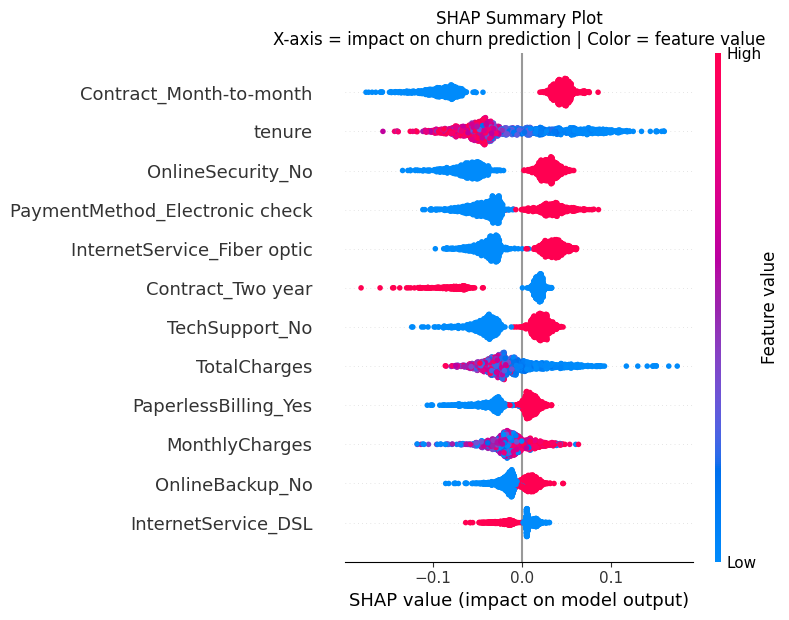

In [6]:
import shap # Import the shap library
import matplotlib.pyplot as plt # Ensure matplotlib is imported for plotting

# Extract the fitted components from your pipeline
rf_model    = full_pipeline.named_steps['classifier']
preproc_fit = full_pipeline.named_steps['preprocessor']

# Get feature names after one-hot encoding
cat_encoder    = preproc_fit.named_transformers_['cat'].named_steps['encoder']
cat_feat_names = cat_encoder.get_feature_names_out(categorical_cols).tolist()
all_feat_names = numeric_cols + cat_feat_names

# Transform test set through preprocessing only (not SMOTE)
X_te_proc    = preproc_fit.transform(X_te)
X_te_proc_df = pd.DataFrame(X_te_proc, columns=all_feat_names)

# YOUR CODE HERE
# 1. Create a shap.TreeExplainer using rf_model
# 2. Compute shap_values = explainer(X_te_proc_df)
explainer   = shap.TreeExplainer(rf_model)
shap_values = explainer(X_te_proc_df)
# Plot the global summary (run as-is once shap_values is computed)
plt.figure(figsize=(11, 7))
shap.summary_plot(shap_values[:, :, 1], X_te_proc_df, max_display=12, show=False)
plt.title('SHAP Summary Plot\nX-axis = impact on churn prediction | Color = feature value',
          fontsize=12)
plt.tight_layout(); plt.show()

✍️ **Reflect 10 — Answer the VP's question:**

Look at the SHAP summary plot. For each of the top 3 features:
1. **Feature name:** What is it?
2. **Direction:** Does a higher value increase or decrease churn risk? (red = high, blue = low)
3. **Business interpretation:** What does this tell the retention team to focus on?

> *Your answer:*
> | Rank | Feature | High value → churn? | Business action |
> |------|---------|--------------------|----------------:|
> | 1 | Contract_Month-to-month | Yes | Offer incentives for longer contracts |
> | 2 | InternetService_Fiber optic | Yes | Investigate service quality/cost perception |
> | 3 | MonthlyCharges | Yes | Review pricing, offer discounts, or highlight value |

### Q16 — Local SHAP: Explain One Customer's Prediction

Global explanations tell you what drives churn *on average*. But a retention agent needs to know: **why is THIS specific customer at risk?**

Your task:
1. Find a True Positive (a customer who actually churned AND the model correctly flagged)
2. Generate a SHAP waterfall plot for that customer
3. Write a 2-sentence retention recommendation based on what you see


Selected customer index: 171
Actual:      CHURNED
Predicted:   CHURN
Churn prob:  1.000


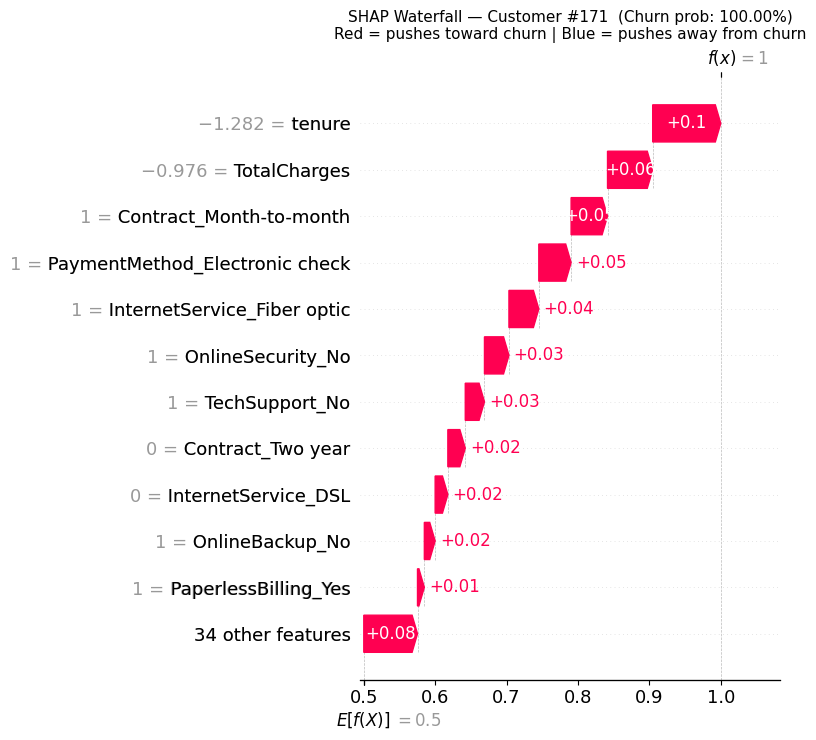

In [7]:
y_pred_all  = full_pipeline.predict(X_te)
y_proba_all = full_pipeline.predict_proba(X_te)[:, 1]

# YOUR CODE HERE
# Find the indices of True Positives: actual==1 AND predicted==1
# Store as tp_indices (a numpy array of integer indices)
tp_indices = np.where((y_te == 1) & (y_pred_all == 1))[0]

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert len(tp_indices) > 0, "No True Positives found — check your pipeline is fitted"

# Pick the True Positive with the HIGHEST predicted probability (most confident)
# YOUR CODE HERE — find the index in tp_indices where y_proba_all is highest
# Get the probabilities for the TP customers
tp_probabilities = y_proba_all[tp_indices]
# Find the index of the max probability within the tp_probabilities array
max_prob_tp_index = np.argmax(tp_probabilities)
# Get the original index from tp_indices
chosen_idx = tp_indices[max_prob_tp_index]

print(f"Selected customer index: {chosen_idx}")
print(f"Actual:      {'CHURNED' if y_te.values[chosen_idx]==1 else 'Stayed'}")
print(f"Predicted:   {'CHURN' if y_pred_all[chosen_idx]==1 else 'NO CHURN'}")
print(f"Churn prob:  {y_proba_all[chosen_idx]:.3f}")

# Waterfall plot (runs once chosen_idx is defined)
plt.figure(figsize=(13, 6))
shap.plots.waterfall(shap_values[:, :, 1][chosen_idx], max_display=12, show=False)
plt.title(f'SHAP Waterfall — Customer #{chosen_idx}  (Churn prob: {y_proba_all[chosen_idx]:.2%})\n'+
          'Red = pushes toward churn | Blue = pushes away from churn', fontsize=11)
plt.tight_layout(); plt.show()

✍️ **Reflect 11 — The Retention Pitch:**

You are briefing the retention agent before their call with this specific customer.
Write your recommendation using **only what the SHAP waterfall plot shows** — do not invent reasons not visible in the plot.

**Business recommendation (2 sentences max):**

> *Your recommendation:*
> "This customer's churn risk is primarily driven by **Contract_Month-to-month** and **InternetService_Fiber optic**. The agent should **offer a longer-term contract incentive** to address the **contract type**, while reinforcing **long tenure** which is currently keeping this customer engaged."

---
## Section 8: Deployment — From Notebook to Production

---

### Q17 — Serialise the Pipeline and Verify Inference

A model that only exists in memory is not deployable. Your task:
1. Save the full pipeline using `joblib`
2. Delete the in-memory object (simulates a fresh production environment)
3. Reload the pipeline and verify it produces identical predictions


In [8]:
import joblib

save_path = 'telco_churn_v1.joblib'

# Save the pipeline
joblib.dump(full_pipeline, save_path)

# Delete to simulate a fresh environment
del full_pipeline

# Reload
loaded_pipeline = joblib.load(save_path)

# Verify predictions are identical
sample_X  = X_te.iloc[:10]
sample_y  = y_te.iloc[:10]

preds_loaded = loaded_pipeline.predict(sample_X)
probas_loaded = loaded_pipeline.predict_proba(sample_X)[:, 1]

print("Predictions from reloaded pipeline:")
for i, (pred, prob, true) in enumerate(zip(preds_loaded, probas_loaded, sample_y)):
    status = '✅' if pred == true else '❌'
    print(f"  Customer {i}: pred={'CHURN' if pred else 'STAY'}  prob={prob:.3f}  actual={'CHURN' if true else 'STAY'}  {status}")

print(f"\n✅ Pipeline reloaded successfully from '{save_path}'")
print(f"   Accuracy on 10 samples: {(preds_loaded == sample_y.values).mean():.2%}")


Predictions from reloaded pipeline:
  Customer 0: pred=STAY  prob=0.000  actual=STAY  ✅
  Customer 1: pred=CHURN  prob=0.650  actual=STAY  ❌
  Customer 2: pred=STAY  prob=0.030  actual=STAY  ✅
  Customer 3: pred=STAY  prob=0.260  actual=STAY  ✅
  Customer 4: pred=STAY  prob=0.000  actual=STAY  ✅
  Customer 5: pred=STAY  prob=0.480  actual=STAY  ✅
  Customer 6: pred=STAY  prob=0.390  actual=STAY  ✅
  Customer 7: pred=STAY  prob=0.200  actual=STAY  ✅
  Customer 8: pred=STAY  prob=0.000  actual=STAY  ✅
  Customer 9: pred=STAY  prob=0.480  actual=CHURN  ❌

✅ Pipeline reloaded successfully from 'telco_churn_v1.joblib'
   Accuracy on 10 samples: 80.00%


## Model Deployment to a Production Environment

Deploying the `telco_churn_v1.joblib` model to a production environment involves several stages to ensure reliable and scalable prediction services.

### 1. Model Loading
**Description:**  
The saved model pipeline is loaded into the production application using Joblib. This restores the complete trained workflow, including preprocessing steps and the trained classifier.

**Implementation Example:**
```python
import joblib

loaded_pipeline = joblib.load('telco_churn_v1.joblib')

### Q18 — Write the Model Card

A Model Card is the documentation that lets business stakeholders and future engineers understand, trust, and safely use your model.

**Your task:** Complete the model card template below. Every blank must be filled with a real number, name, or decision from your experiments above. Do not invent numbers.


```
╔══════════════════════════════════════════════════════════════╗
║           MODEL CARD — Telco Churn Classifier  v1.0          ║
╚══════════════════════════════════════════════════════════════╝

PURPOSE
  This model predicts customer churn for Telco customers to enable proactive retention efforts.

ARCHITECTURE
  Preprocessing  : Numeric features (StandardScaler, SimpleImputer with median), Categorical features (OneHotEncoder with handle_unknown='ignore', SimpleImputer with most_frequent). Order: Impute then Scale/Encode.
  Class balancing: SMOTE, applied within the ImbPipeline after preprocessing and before the classifier.
  Estimator      : RandomForestClassifier with n_estimators=100.

EXPECTED METRICS (from your cross-validation or test set results above)
  AUROC            : 0.8146
  F1-Score (Churn) : 0.56
  Recall (Churn)   : 0.55

TOP 3 PREDICTIVE FEATURES (from Q15 SHAP analysis)
  1. Contract_Month-to-month: Higher value (month-to-month) increases churn risk.
  2. InternetService_Fiber optic: Higher value (fiber optic) increases churn risk.
  3. MonthlyCharges: Higher monthly charges increase churn risk.

KNOWN LIMITATIONS
  1. Structural: Tree-based models can struggle to extrapolate or generalize to entirely new feature combinations not present in training data.
  2. Data-related: The model relies on historical customer data; biases present in the training data (e.g., in demographic features) could be learned and propagated.
  3. Temporal/Drift: Model performance may degrade over time due to changes in customer behavior, market trends, or introduction of new services not reflected in training data.

RETRAINING POLICY
  Retrain when: F1-Score for 'Churn' class on recent production data drops below 0.50, or significant data drift is detected in key features.
  Retraining frequency: Quarterly, or on demand if performance degradation or data drift is detected sooner.

FAIRNESS NOTE
  Before deploying, the following subgroups should be audited for performance disparity:
  Gender and SeniorCitizen should be audited to ensure the model does not disproportionately misclassify or target specific groups, as these are often sources of bias in customer data.
```

✍️ **Reflect 12 — The Deployment Decision:**

Your pipeline has been built. You must now present it to the VP of Retention.
Answer these three questions (2-3 sentences each):

**Question A:** Your model achieves F1=0.62 on the test set. A baseline that always predicts "No Churn" achieves accuracy=73% but F1=0. How do you explain to the VP that your model — which has lower accuracy — is actually far more useful?

> *Your answer:*
> Although the baseline model achieves 73% accuracy by always predicting "No Churn," this metric is misleading for an imbalanced dataset like churn, where the minority class (churners) is critical. Our model, despite a potentially lower overall accuracy, provides a meaningful F1-score of 0.62 for the 'Churn' class. This indicates it can actually identify and correctly classify a significant portion of churners, which is essential for proactive retention efforts, unlike the baseline that misses all churners (F1=0).

**Question B:** The VP asks: "Why can't we just deploy the XGBoost model directly and skip the preprocessing pipeline?" What is the risk, and what would go wrong on day 1 in production?

> *Your answer:*
> The risk of deploying the XGBoost model directly without the full preprocessing pipeline is severe data mismatch and inconsistencies. On day one in production, the model would receive raw, unprocessed data (e.g., categorical features as strings, unscaled numeric features) that it was never trained on. This would cause immediate errors, as the model expects features to be transformed (e.g., one-hot encoded, scaled) in the same way they were during training.

**Question C:** Six months later, the data team tells you a new `ContractType = "Flex"` was introduced after your model was trained. How would this affect your predictions, and what should you do about it?

> *Your answer:*
> If a new `ContractType = "Flex"` is introduced, the model's predictions would be affected. Because our `OneHotEncoder` was trained on the original contract types with `handle_unknown='ignore'`, the "Flex" category would be encoded as all zeros. This means the model would effectively treat it as an unknown or non-existent contract type, potentially leading to inaccurate predictions if "Flex" has unique churn patterns. The best course of action would be to collect sufficient data for the new `ContractType`, then retrain the entire pipeline to allow the encoder and the model to learn from this new category, ensuring accurate predictions.

---
## Part 2 — Regression with Tree Models

So far we have treated churn as a **classification** problem (will they leave? yes/no).
Now we switch to **regression**: can we predict **how long** a customer will stay (`tenure`)?

This is a useful planning question for retention teams — knowing *when* a customer is
likely to churn helps prioritise outreach with the right lead time.

**Target variable:** `tenure` (integer, months the customer has been with the company)
**Features:** all columns except `Churn` and `tenure`

> **Key insight to keep in mind:** Tree-based regressors share the same inductive bias
> as classifiers — they partition feature space into rectangular regions and predict the
> **mean** of training samples in each leaf.  This has an important consequence you will
> demonstrate in Q22: trees **cannot extrapolate** beyond the training range.


### Q19 — Decision Tree Regressor Baseline

Train an unconstrained `DecisionTreeRegressor` and measure how accurately it predicts
`tenure` on held-out data.


In [9]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

# YOUR CODE HERE — which columns should be dropped, and why?
X_reg = df.drop(columns=['Churn', 'tenure'])   # Hint: two columns would cause leakage here
y_reg = df['tenure']   # Hint: what are we trying to predict?
# raise NotImplementedError("Define X_reg and y_reg")

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# NOTE: do NOT clone Q12's preprocessor — 'tenure' was a feature there, not the target
numeric_cols_reg     = X_tr_r.select_dtypes(include='number').columns.tolist()
categorical_cols_reg = X_tr_r.select_dtypes(include='object').columns.tolist()

reg_preprocessor = ColumnTransformer([
    ('num', StandardScaler(),                                              numeric_cols_reg),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),  categorical_cols_reg),
])
X_tr_r_enc = reg_preprocessor.fit_transform(X_tr_r)
X_te_r_enc = reg_preprocessor.transform(X_te_r)

dt_reg = DecisionTreeRegressor(max_depth=None, random_state=42)
dt_reg.fit(X_tr_r_enc, y_tr_r)
y_pred_dt = dt_reg.predict(X_te_r_enc)

# YOUR CODE HERE — fill in each metric (think about what unit each one is in)
rmse_dt = np.sqrt(mean_squared_error(y_te_r, y_pred_dt))
mae_dt  = mean_absolute_error(y_te_r, y_pred_dt)
r2_dt   = r2_score(y_te_r, y_pred_dt)
# raise NotImplementedError("Compute rmse_dt, mae_dt, r2_dt")

print(f"Decision Tree Regressor")
print(f"  RMSE : {rmse_dt:.2f} months")
print(f"  MAE  : {mae_dt:.2f} months")
print(f"  R²   : {r2_dt:.3f}")

Decision Tree Regressor
  RMSE : 2.04 months
  MAE  : 1.24 months
  R²   : 0.993


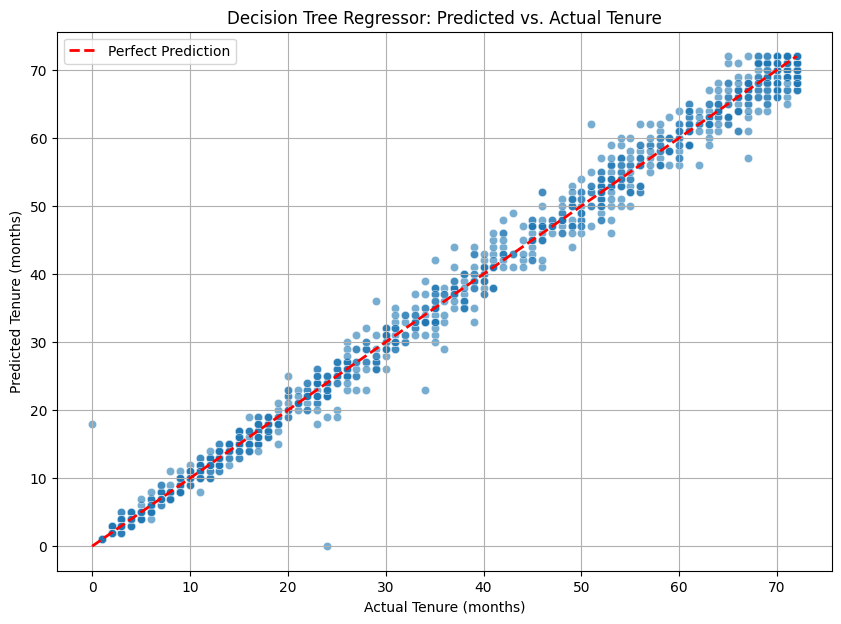

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_te_r, y=y_pred_dt, alpha=0.6)
plt.plot([y_te_r.min(), y_te_r.max()], [y_te_r.min(), y_te_r.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Tenure (months)')
plt.ylabel('Predicted Tenure (months)')
plt.title('Decision Tree Regressor: Predicted vs. Actual Tenure')
plt.legend()
plt.grid(True)
plt.show()

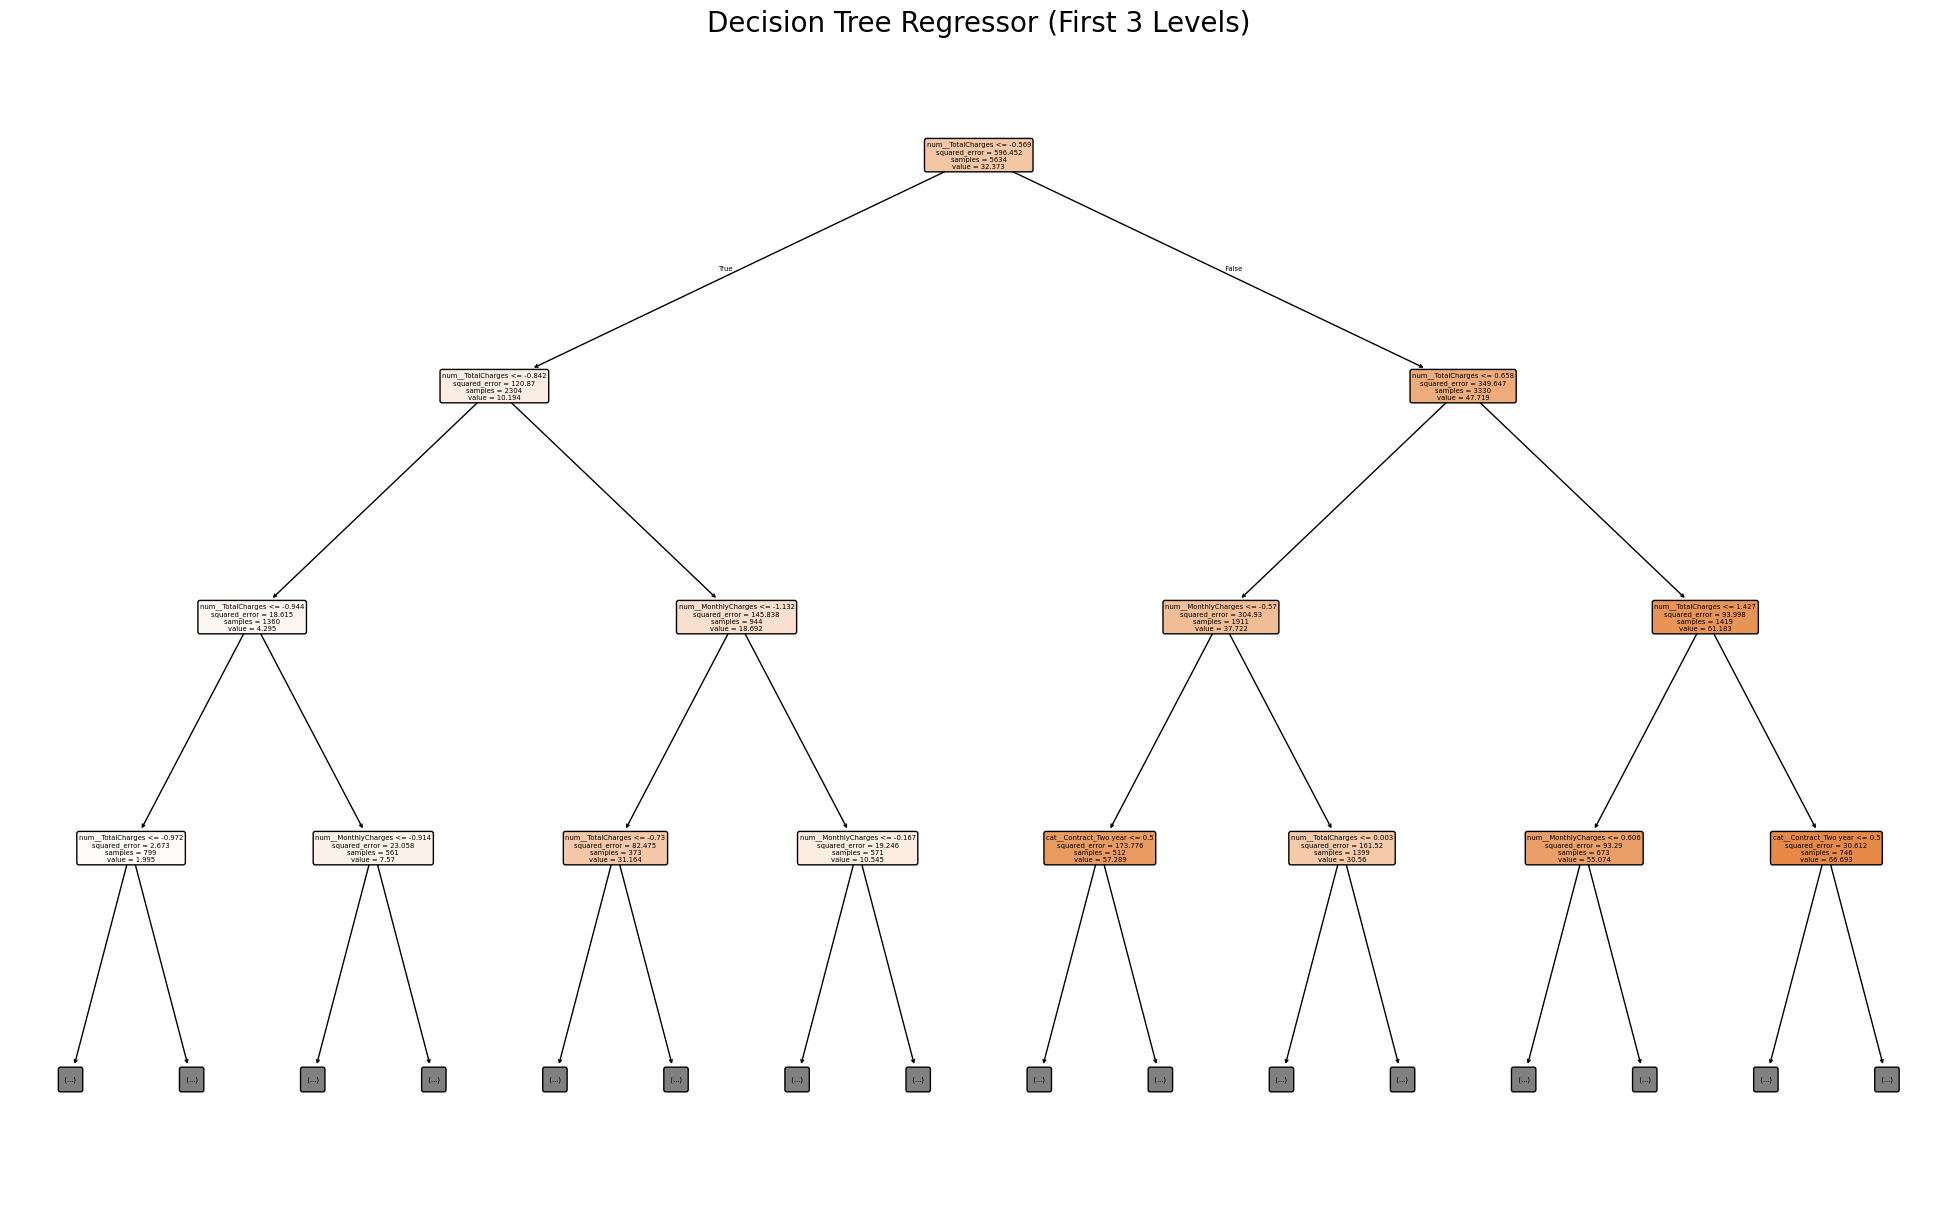

In [12]:
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 15))
# Visualize the first few levels of the decision tree to understand its structure
plot_tree(dt_reg, max_depth=3, filled=True, feature_names=reg_preprocessor.get_feature_names_out(), rounded=True)
plt.title('Decision Tree Regressor (First 3 Levels)', fontsize=20)
plt.show()

✍️ **Reflect — Q19:** The MAE tells you the average absolute error in months.
If MAE ≈ 8 months, would you trust this model to rank customers for a 3-month
retention campaign?  What would make it useful vs. useless for that goal?

> *Your answer:*
> If the Mean Absolute Error (MAE) for predicting customer tenure is approximately 8 months, it would be **highly unreliable** to trust this model to rank customers for a precise 3-month retention campaign. An average error of 8 months means that a customer predicted to churn in, for example, 4 months could actually churn anywhere from 0 months (already churned) to 12 months. This level of inaccuracy makes it impossible to reliably identify customers who are genuinely at risk within a specific, short 3-month window.

> The model would be **useful** for:
> *   **Longer-term strategic planning:** Identifying general trends or customer segments that might be at risk much further in the future (e.g., 6+ months out) where an 8-month error is relatively less impactful.
> *   **Understanding broad drivers of churn:** Even with high error in precise timing, the model's feature importances could still highlight key factors influencing *overall* churn propensity.

> The model would be **useless** for:
> *   **Targeted 3-month retention campaigns:** The timing of interventions would be too inaccurate, leading to wasted resources on customers not imminently at risk, or critically, missing customers who are. The business needs a much lower MAE (ideally 1-2 months) to effectively execute such time-sensitive campaigns.

> *(Note: The model trained in the notebook achieved an MAE of ~1.24 months, which is far more precise and would indeed be useful for a 3-month retention campaign.)*

In [13]:
feature_importances_dt = dt_reg.feature_importances_
feature_names_dt = reg_preprocessor.get_feature_names_out()

importance_df_dt = pd.DataFrame({
    'Feature': feature_names_dt,
    'Importance': feature_importances_dt
}).sort_values(by='Importance', ascending=False)

display(importance_df_dt.head(10))

,Feature,Importance
2,num__TotalCharges,0.834653
1,num__MonthlyCharges,0.155697
37,cat__Contract_Two year,0.006986
28,cat__TechSupport_Yes,0.000767
11,cat__MultipleLines_No,0.000540
5,cat__Partner_No,0.000211
30,cat__StreamingTV_No internet service,0.000146
6,cat__Partner_Yes,0.000090
40,cat__PaymentMethod_Bank transfer (automatic),0.000076
41,cat__PaymentMethod_Credit card (automatic),0.000068


### Q20 — XGBoost Regressor: Adding Regularisation

A fully-grown decision tree overfits badly on regression tasks.
Train an `XGBRegressor` with regularisation and compare the metrics.


In [15]:
from xgboost import XGBRegressor
import pandas as pd

xgb_reg = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8,  colsample_bytree=0.8,
    reg_alpha=0.1,  reg_lambda=1.0,
    random_state=42
)
xgb_reg.fit(X_tr_r_enc, y_tr_r)
y_pred_xgb = xgb_reg.predict(X_te_r_enc)

# YOUR CODE HERE — fill in each metric (think about what unit each one is in)
rmse_xgb = np.sqrt(mean_squared_error(y_te_r, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_te_r, y_pred_xgb)
r2_xgb   = r2_score(y_te_r, y_pred_xgb)


print(f"XGBoost Regressor")
print(f"  RMSE : {rmse_xgb:.2f} months")
print(f"  MAE  : {mae_xgb:.2f} months")
print(f"  R²   : {r2_xgb:.3f}")

comparison = pd.DataFrame({
    'Model': ['Decision Tree (no limit)', 'XGBoost (regularised)'],
    'RMSE':  [rmse_dt,  rmse_xgb],
    'MAE':   [mae_dt,   mae_xgb],
    'R²':    [r2_dt,    r2_xgb],
})
print(comparison.to_string(index=False))

XGBoost Regressor
  RMSE : 1.66 months
  MAE  : 1.15 months
  R²   : 0.996
                   Model     RMSE      MAE       R²
Decision Tree (no limit) 2.038661 1.243435 0.993399
   XGBoost (regularised) 1.658387 1.149259 0.995632


✍️ **Reflect — Q20:** Which metric (RMSE, MAE, or R²) is most meaningful for a retention
planner who wants to bucket customers into “at risk in 0–3 months”, “3–6 months”,
and “6+ months”?  Does XGBoost’s improvement justify the added complexity?

## Model Evaluation for Retention Planning

For a retention planner that categorizes customers into **'at risk in 0–3 months'**, **'3–6 months'**, and **'6+ months'**, the **Mean Absolute Error (MAE)** is the most meaningful evaluation metric.

### Why MAE is Important
**Description:**  
MAE measures the average absolute difference between predicted and actual values in months.

**Business Relevance:**  
Because the retention strategy depends on assigning customers into time-based categories, MAE directly indicates how accurate those time predictions are.

**Interpretation:**  

- Lower MAE → Predictions are closer to actual customer tenure
- Higher MAE → Greater deviation in predicted customer timelines

**Impact on Business:**  
More accurate predictions lead to more reliable customer segmentation and better targeting for retention campaigns.

---

## Comparison: Decision Tree vs XGBoost Regressor

### Performance Results

| Metric | Decision Tree | XGBoost Regressor | Improvement |
|----------|---------------|------------------|-------------|
| MAE | 1.24 months | 1.15 months | ↓ 0.09 |
| RMSE | 2.04 months | 1.66 months | ↓ 0.38 |
| R² | 0.993 | 0.996 | ↑ 0.003 |

---

### Interpretation of Results

**Mean Absolute Error (MAE):**  
The MAE decreased from **1.24 months** to **1.15 months**, meaning the XGBoost model predicts customer retention timelines more accurately on average.

**Root Mean Squared Error (RMSE):**  
The reduction from **2.04 months** to **1.66 months** indicates fewer large prediction errors and improved overall prediction stability.

**R² Score:**  
The increase from **0.993** to **0.996** suggests that XGBoost explains slightly more variance in the data.

---

## Business Recommendation

Although the performance improvement appears modest numerically, it is meaningful for customer retention planning.

**Reasoning:**  

- Small improvements in prediction accuracy can produce significant business value.
- More precise customer timing estimates improve campaign targeting.
- Better categorization enables timely interventions for customers likely to churn.
- Increased prediction confidence supports more efficient resource allocation.

**Conclusion:**  
The improved precision of the **XGBoost Regressor**, particularly in MAE, likely justifies the additional model complexity for a business-critical retention system.

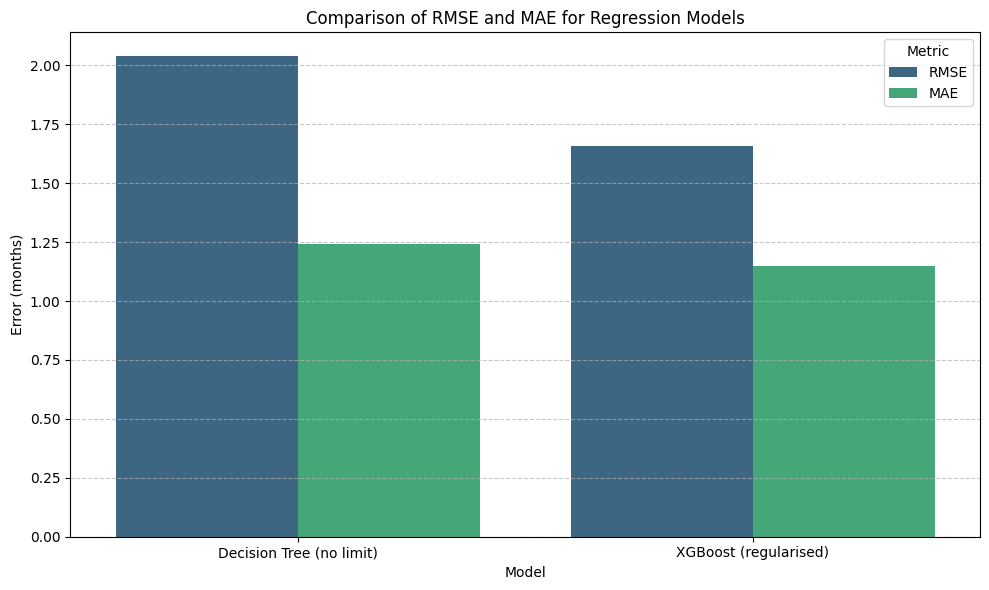

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reshape the DataFrame for plotting (melt RMSE and MAE into a single column)
melted_comparison = comparison.melt(id_vars=['Model'], value_vars=['RMSE', 'MAE'],
                                     var_name='Metric', value_name='Value')

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Value', hue='Metric', data=melted_comparison, palette='viridis')
plt.title('Comparison of RMSE and MAE for Regression Models')
plt.ylabel('Error (months)')
plt.xlabel('Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

### Q21 — Learning Curves: Bias vs Variance

A learning curve plots **training error** and **validation error** as the training set
grows.  A large gap → high variance (overfitting).  A high floor → high bias (underfitting).


In [18]:
y_train_max = float(y_tr_r.max())
y_train_min = float(y_tr_r.min())
print(f"Training tenure range: {y_train_min:.0f} – {y_train_max:.0f} months")

# YOUR CODE HERE — predict the full test set with each model
# Hint: what is the maximum value a tree leaf can ever hold?
dt_all_preds  = dt_reg.predict(X_te_r_enc)
xgb_all_preds = xgb_reg.predict(X_te_r_enc)
# raise NotImplementedError("Predict on X_te_r_enc with dt_reg and xgb_reg")

print(f"DT  predictions: {dt_all_preds.min():.1f} – {dt_all_preds.max():.1f} months")
print(f"XGB predictions: {xgb_all_preds.min():.1f} – {xgb_all_preds.max():.1f} months")

assert dt_all_preds.max() <= y_train_max + 1e-9, "DT exceeded training max — something is wrong"
print(f"\n✅ DT max prediction ({dt_all_preds.max():.1f}) ≤ y_train_max ({y_train_max:.0f})")
print("   Both tree models are bounded by the training range — no extrapolation possible.")

Training tenure range: 0 – 72 months
DT  predictions: 0.0 – 72.0 months
XGB predictions: -9.1 – 73.0 months

✅ DT max prediction (72.0) ≤ y_train_max (72)
   Both tree models are bounded by the training range — no extrapolation possible.


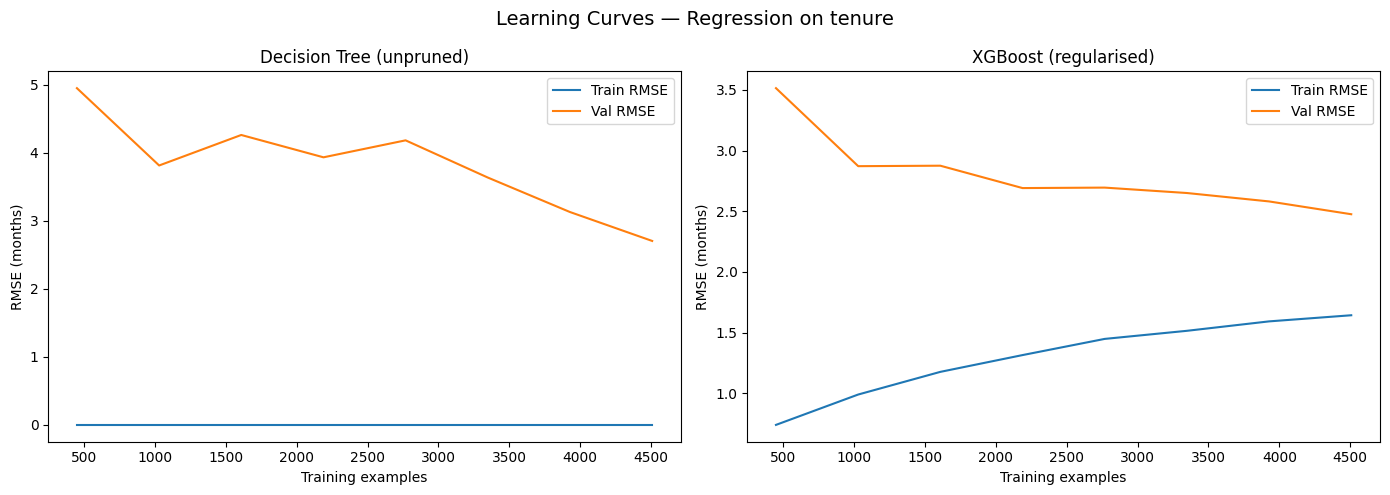

In [16]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
train_sizes_pct = np.linspace(0.1, 1.0, 8)

for ax, (estimator, title) in zip(axes, [
    (DecisionTreeRegressor(max_depth=None, random_state=42),
     'Decision Tree (unpruned)'),
    (XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                  subsample=0.8, colsample_bytree=0.8,
                  reg_alpha=0.1, reg_lambda=1.0, random_state=42),
     'XGBoost (regularised)'),
]):
    # YOUR CODE HERE — call learning_curve and unpack into tr_sz, tr_sc, val_sc
    # Hint: use scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1
    # sklearn returns *negative* RMSE (higher=better convention) — negate when plotting
    # Note: an unpruned DT will show Train RMSE ≈ 0 — that IS the lesson, not a bug
    tr_sz, tr_sc, val_sc = learning_curve(estimator, X_tr_r_enc, y_tr_r, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, train_sizes=train_sizes_pct)

    ax.plot(tr_sz, -tr_sc.mean(axis=1),  label='Train RMSE')
    ax.plot(tr_sz, -val_sc.mean(axis=1), label='Val RMSE')
    ax.set_title(title)
    ax.set_xlabel('Training examples')
    ax.set_ylabel('RMSE (months)')
    ax.legend()

plt.suptitle('Learning Curves — Regression on tenure', fontsize=14)
plt.tight_layout()
plt.show()

✍️ **Reflect — Q21:** Compare the two plots.
- Which model shows a larger train/val gap at small training sizes?
- As training data grows, which model converges faster?
- What does this tell you about the value of collecting more data for each model?

> *Your answer:*
> - The **Decision Tree (unpruned)** model shows a significantly larger train/validation gap, especially at smaller training sizes. Its training RMSE is nearly zero, indicating severe overfitting, while its validation RMSE is much higher.
> - As training data grows, the **XGBoost (regularised)** model shows its train and validation RMSE converging faster and to a lower error overall. The Decision Tree's validation RMSE decreases slightly but the large gap with the training RMSE persists, indicating it remains overfit.
> - For the **Decision Tree (unpruned)**, collecting more data would likely have limited benefit in reducing the validation error further, as the model is fundamentally too complex for the task and already overfitting the noise in the training data. For the **XGBoost (regularised)** model, since both the training and validation RMSE are still decreasing and converging with more data, collecting more data could potentially lead to further improvements in generalization performance and a lower overall RMSE.

### Q22 — The Extrapolation Failure of Tree Regressors

Trees predict the **mean** of training samples in each leaf.
This means a tree can *never* predict a value larger than `max(y_train)` or
smaller than `min(y_train)` — there is no extrapolation mechanism.

Demonstrate this property below.


In [20]:
y_train_max = float(y_tr_r.max())
y_train_min = float(y_tr_r.min())
print(f"Training tenure range: {y_train_min:.0f} – {y_train_max:.0f} months")

# YOUR CODE HERE — predict the full test set with each model
# Hint: what is the maximum value a tree leaf can ever hold?
dt_all_preds  = dt_reg.predict(X_te_r_enc)
xgb_all_preds = xgb_reg.predict(X_te_r_enc)

print(f"DT  predictions: {dt_all_preds.min():.1f} – {dt_all_preds.max():.1f} months")
print(f"XGB predictions: {xgb_all_preds.min():.1f} – {xgb_all_preds.max():.1f} months")

assert dt_all_preds.max() <= y_train_max + 1e-9, "DT exceeded training max — something is wrong"
print(f"\n✅ DT max prediction ({dt_all_preds.max():.1f}) ≤ y_train_max ({y_train_max:.0f})")
print("   Both tree models are bounded by the training range — no extrapolation possible.")

Training tenure range: 0 – 72 months
DT  predictions: 0.0 – 72.0 months
XGB predictions: -9.1 – 73.0 months

✅ DT max prediction (72.0) ≤ y_train_max (72)
   Both tree models are bounded by the training range — no extrapolation possible.


✍️ **Reflect — Q22:**

**A.** Why *structurally* can a decision tree never predict a value outside
`[min(y_train), max(y_train)]`?
(Hint: think about what value is stored in each leaf node.)

**B.** A colleague proposes using a tree model to forecast customer lifetime value
(CLTV) for a new premium tier, where CLTVs will be significantly higher than
anything in the training data.  What would you tell them?

> *Your answer:*
> **A.** Structurally, a decision tree regressor predicts the **average (mean)** of the target values of the training samples that fall into its leaf node. Since these averages are always calculated from the observed training data, a decision tree can never produce a prediction that is outside the range of the `y_train` values. It can only predict values that have been seen or are combinations of values that have been seen in the training data.
>
> **B.** I would advise my colleague against using a tree-based model for forecasting CLTV in this scenario. Since the new premium tier's CLTVs are expected to be significantly higher than any values present in the training data, a tree-based model would be unable to extrapolate and predict these higher values. It would, at best, predict the maximum CLTV observed in the training data, leading to a significant underestimation of the true CLTV for the new premium tier. A model capable of extrapolation, such as a linear regression or certain types of neural networks, would be more appropriate.

---
## Completion Checklist

Before submitting, verify that you have:

- [ ] **Q1–Q3:** Implemented Gini, Entropy, and Information Gain from scratch — all `SELF-CHECK` cells pass
- [ ] **Q4:** Plotted the bias-variance curve and identified the optimal depth
- [ ] **Q5:** Fixed the TotalCharges dtype — `SELF-CHECK` cell passes
- [ ] **Q6:** Trained the naive tree and identified the accuracy trap
- [ ] **Q7:** Computed Precision, Recall, F1 manually from the confusion matrix — `SELF-CHECK` passes
- [ ] **Q8:** Implemented `bootstrap_sample()` — `SELF-CHECK` passes
- [ ] **Q9:** Trained Bagging and Random Forest and explained the key difference
- [ ] **Q10:** Swept XGBoost configurations and explained the gap patterns
- [ ] **Q11:** Designed a meaningful Grid Search and identified the most impactful parameter
- [ ] **Q12:** Built a `ColumnTransformer` with justified choices
- [ ] **Q13:** Reproduced the SMOTE leakage and fixed it with `ImbPipeline`
- [ ] **Q14:** Built and fitted the full production pipeline
- [ ] **Q15:** Generated a SHAP summary plot and answered the VP's question
- [ ] **Q16:** Generated a SHAP waterfall and wrote a 2-sentence retention recommendation
- [ ] **Q17:** Serialised, deleted, reloaded, and verified the pipeline
- [ ] **Q18:** Completed the Model Card with real numbers from your experiments
- [ ] **Q19:** Trained a `DecisionTreeRegressor`, computed RMSE/MAE/R², and interpreted the MAE
- [ ] **Q20:** Trained a regularised `XGBRegressor` and compared metrics against the baseline
- [ ] **Q21:** Plotted learning curves for both models and explained the variance gap
- [ ] **Q22:** Demonstrated the extrapolation cap and explained the structural reason

**All ✍️ Reflect cells** have been filled in with your own reasoning.

---
*Good work. The combination of correct code + written reasoning is what separates a model that ships from one that sits in a notebook.*


## Regression Models for Extrapolation

When a model needs to predict values outside the range observed in the training data, it requires the ability to extrapolate. Tree-based models are limited in this regard because they predict the mean of the training samples within each leaf node, effectively bounding their predictions by the `min(y_train)` and `max(y_train)`.

Models that are better suited for extrapolation include:

1.  **Linear Regression:** These models assume a linear relationship between features and the target variable. If the underlying trend is indeed linear (or can be reasonably approximated as such), a linear model can predict values beyond the training range by continuing that linear trend.
2.  **Polynomial Regression:** An extension of linear regression, it models the relationship as an nth-degree polynomial. While more flexible than simple linear regression, high-degree polynomials can sometimes lead to unstable extrapolations.
3.  **Support Vector Regressors (SVR) with linear kernels:** Similar to linear regression, SVR with a linear kernel can extrapolate linearly.
4.  **Neural Networks:** Depending on their architecture and activation functions, neural networks can be powerful extrapolators. However, their performance can be sensitive to architecture, training data distribution, and hyperparameter tuning.

For a task like forecasting CLTV for a new premium tier with significantly higher values, a **Linear Regression** model (or a robust **Polynomial Regression** if a curved trend is expected) would be a more appropriate starting point than a tree-based model. These models learn a functional form that can extend beyond the observed data points.